# JC3503 Assignment 


---

Student Name: Geng Yiwei
Student Email: 2676129376@qq.com

Student ID: 50091136

<u>**Due Date: 2026/06/01**</u>

---

**This file should be renamed to your student ID (e.g. '50080001.ipynb')**



You should use markdown to explain the different steps of your analysis, and to add your own interpretation of what that analysis shows. 

Your notebook should alternate between markdown and analysis code. However, you should also use code comments, where appropriate, to explain your process.

**Note that all comments and markdown should be in English.**

### Part 1 — Initial setup

This section wires up libraries, reusable helpers, default plotting style, and a clean load of `games.csv` into `df_raw` (immutable backup) and `df` (working copy).

第一部分：完成库导入、全局辅助函数、基础绘图样式，以及将 `games.csv` 读入 `df_raw` 并复制为工作表 `df`。

#### 1.1 Module imports

Import core libraries for tables, arrays, plotting, statistics, and machine learning used later in the notebook.

导入后续分析常用的数据处理、可视化、统计与机器学习相关库。

In [1]:
# Core numerics & tables
import json

import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics & ML (used in later sections)
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#### 1.2 Global helper functions

Define shared constants (`DATA_PATH`, `RANDOM_STATE`), safe dataframe copying, a missing-value summary, and x-axis label rotation for crowded plots.

定义全局常量、DataFrame 备份、缺失概览与横轴标签旋转等全文复用的小工具。

In [2]:
# --- Paths & reproducibility ---
DATA_PATH = "games.csv"
RANDOM_STATE = 42


def dataframe_checkpoint(frame: pd.DataFrame) -> pd.DataFrame:
    """Return an independent copy for safe downstream transforms."""
    return frame.copy()


def missingness_summary(frame: pd.DataFrame) -> pd.DataFrame:
    """Missing count and percentage for columns with at least one NA."""
    n = len(frame)
    miss = frame.isna().sum()
    out = pd.DataFrame({"missing": miss, "pct": (miss / n) * 100.0})
    return out.loc[miss > 0].sort_values("missing", ascending=False)


def rotate_x_labels_if_needed(
    ax,
    *,
    angle: float = 45.0,
    ha: str = "right",
    max_label_chars: int = 10,
    min_tick_count: int = 8,
) -> None:
    """Rotate x tick labels clockwise only when labels are long or numerous."""
    labels = [t.get_text() for t in ax.get_xticklabels() if t.get_text()]
    if not labels:
        return
    if max((len(s) for s in labels), default=0) > max_label_chars or len(labels) >= min_tick_count:
        plt.setp(ax.get_xticklabels(), rotation=angle, ha=ha)


def rotate_x_labels(ax, angle: float = 45.0, ha: str = "right") -> None:
    """Alias for rotate_x_labels_if_needed (do not force rotation on short axes)."""
    rotate_x_labels_if_needed(ax, angle=angle, ha=ha)

#### 1.3 Global plotting style

Apply Seaborn `whitegrid` and Matplotlib `rcParams` defaults for figure size, DPI, and font sizes used across figures.

统一 Seaborn 主题与 Matplotlib 全局参数（图幅、分辨率、字号），保证全文图表风格一致。

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)

#### 1.4 Dataset loading

Read `games.csv` into `df_raw`, then copy to `df` for all mutable work so the raw snapshot stays recoverable.

从 CSV 读入 `df_raw`，再 `copy()` 得到工作副本 `df`，避免后续清洗破坏原始快照。

In [4]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False, encoding="utf-8")
df = df_raw.copy()

## Section 2: Structured inventory of the extract

This section carries out an overall, comprehensive exploratory data analysis (EDA) of the database in six layers, covering: sampling-based observation, dataset shape, data types, functional grouping of column names, numeric and text spans together with floating-point precision, character encoding and multilingual fields, simple data mining, and finally observation of missing and erroneous values.

本节按六个层次对数据库进行总体上的全面的EDA分析。包括：抽样观察和数据集形状，数据类型和列名职能归类，数值与文本跨度及浮点精度，字符编码与多语言字段，简单的数据挖掘，最后是对缺失和错误值的观察。



### 2.1 Sampling observation and dataset shape

Before the overall analysis, I inspect fragments of the dataset to help set later research directions. I read the first five rows, the last five rows, and five rows drawn at random from the middle of the table; those middle five are sampled from the **25%–75%** row-index band. Finally I call `shape` to record how many rows and columns the frame contains.

在整体分析之前，先选取一些数据集的片段来进行观察，以确定后续的研究方向。我们读取前五行，后五行和随机抽样中间的五行来研究。中间五行将出自25%-75%的区间。最后用shape命令看一下数据集的形状。



In [5]:
# Section 2.1 — head, tail, middle-band sample, then shape
from IPython.display import display

n_rows = len(df)
mid_lo = n_rows // 4
mid_hi = (3 * n_rows) // 4

head_five = df.head(5)
tail_five = df.tail(5)
middle_five = df.iloc[mid_lo:mid_hi].sample(5, random_state=RANDOM_STATE)

print("【test log】 total rows:", n_rows)
print("【test log】 middle band row-index range (iloc):", mid_lo, "to", mid_hi - 1)
print("【test log】 middle-band size (rows):", mid_hi - mid_lo)
print("【test log】 sampled middle row indices:", middle_five.index.tolist())

print("\n--- First five rows ---")
display(head_five)

print("\n--- Last five rows ---")
display(tail_five)

print("\n--- Random five rows from middle band (25%–75%) ---")
display(middle_five)

print("\n--- Dataset shape ---")
print("【test log】 df.shape (rows, columns)")
print(df.shape)


【test log】 total rows: 122611
【test log】 middle band row-index range (iloc): 30652 to 91957
【test log】 middle-band size (rows): 61306
【test log】 sampled middle row indices: [65630, 38015, 63241, 62619, 71430]

--- First five rows ---


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN



--- Last five rows ---


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
122606,4152910,完美传奇,"Jan 4, 2026",0 - 0,0,0,0.00,0,0,《完美传奇》游戏介绍 🔥【完美传奇——专属大陆的奇幻史诗！】🔥 🌍耗时两年匠心打造，诚意之作...,...,0,0,0,完美传奇,完美传奇,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Action,Adventure,Massively Multiplayer,RPG,Sim...",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
122607,4042800,Poker Fate - ACG Texas Hold'em,"Jan 3, 2026",0 - 0,0,0,0.00,0,0,Poker Fate – Choose your poker partner and ent...,...,0,0,0,©7 Points Digital Tech Limited,©7 Points Digital Tech Limited,"Multi-player,PvP,Online PvP,Cross-Platform Mul...","Casual,Strategy,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
122608,3522550,Adira Nusantara,"Jan 3, 2026",0 - 0,0,0,7.99,0,0,(Gif character) Adira Nusantara is a side-scro...,...,0,0,0,Arraubi Gameware,Arraubi Gameware,"Single-player,Custom Volume Controls,Narrated ...","Action,Adventure,Casual,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
122609,3680350,A Lenda de Niterói,"Jan 4, 2026",0 - 0,0,0,2.09,0,0,"Step into the role of Arariboia, a legendary I...",...,0,0,0,Seven Moons,Seven Moons,"Single-player,Full controller support,Family S...","Action,Adventure,Casual,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
122610,4141790,[BEAT:KEEPER],"Jan 5, 2026",0 - 0,0,0,0.00,0,0,Exhibited at Vantan Game Academy – TOKYO GAME ...,...,0,0,0,Vantan Game Academy,Vantan Game Academy,"Single-player,Partial Controller Support","Action,Indie,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN



--- Random five rows from middle band (25%–75%) ---


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
65630,2626530,Legendary Tales: Stories Collector's Edition,"Apr 26, 2024",0 - 20000,2,0,9.99,0,0,"Defeat the unknown illnesses, break the unseen...",...,0,0,0,FIVE-BN GAMES,FIVE-BN GAMES,"Single-player,Steam Achievements,Steam Cloud,F...","Adventure,Casual","Casual,Adventure,Point & Click,Puzzle,Hidden O...",https://shared.akamai.steamstatic.com/store_it...,NaN
38015,1766060,HumanitZ,"Sep 18, 2023",200000 - 500000,740,0,12.99,35,0,A zombie outbreak wiped out civilization as we...,...,40,217,40,Yodubzz Studios,indie.io,"Single-player,Multi-player,PvP,Online PvP,Co-o...","Action,Adventure,RPG,Early Access","Early Access,Survival,Zombies,Open World,Multi...",https://shared.akamai.steamstatic.com/store_it...,NaN
63241,2286540,Destiny Duel,"Mar 17, 2023",0 - 0,0,0,0.00,0,1,Destiny Duel is a PvP psychological strategy g...,...,0,0,0,Master Bronze Elite,MBE Games,"Multi-player,PvP,Online PvP,Steam Achievements...","Free To Play,Indie,Strategy",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
62619,2416100,Goodnight Universe,"Nov 11, 2025",0 - 0,0,0,15.99,0,1,From the creators of Before Your Eyes . You ar...,...,0,0,0,Nice Dream,Skybound Games,"Single-player,Steam Achievements,Full controll...","Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
71430,1215990,RhythmDanceVR,"Feb 5, 2020",0 - 20000,0,0,14.99,0,0,RhythmDanceVR is an explosively loaded dance g...,...,0,0,0,VRA-Games,VRA-Games,"Single-player,Tracked Controller Support,VR On...","Indie,Simulation,Sports,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN



--- Dataset shape ---
【test log】 df.shape (rows, columns)
(122611, 40)


`df.shape` fixes the catalogue at **122,611** listings by **40** attributes, so every later rate or count can be scaled against that denominator. The three row slices all use the same column layout but are not interchangeable: the head and tail follow file order (indices **0–4** and **122,606–122,610**), while the middle five are drawn only from the **25%–75%** band (indices **30,652–91,956**, then `sample` with `RANDOM_STATE`; **【test log】** row labels **65,630; 38,015; 63,241; 62,619; 71,430**). In each slice, long text and URL fields sit next to numeric telemetry, and `NaN` often appears in narrative or media columns even when `AppID`, price, and vote fields are filled—so the full EDA still has to treat missingness and parsing explicitly.

`shape` 给出 **122,611** 行、**40** 列，后续占比与计数都应对这一总体计量。三段行切片列结构相同、内容却不等价：前五行与后五行沿文件物理顺序（**0–4** 与 **122,606–122,610**）；中间五行仅在 **25%–75%** 行带（**30,652–91,956**）内随机抽取（`RANDOM_STATE` 固定；【test log】 行号 **65,630、38,015、63,241、62,619、71,430**）。各段均见长文本/链接列与数值列并存，简介或媒体列常有 `NaN` 而 `AppID`、价格、票数仍可填——全面 EDA 仍须单独处理缺失与类型解析。



### 2.2 Data types and column names

This step examines the **40** column names together with their pandas storage types. I first inventory which dtypes appear in the frame, then scan each column for abnormal mixing—whether non-null cells carry more than one Python runtime type in the same field.

这一步将对40列的数据类型和列名进行研究。首先确定有哪些数据类型，并排除一下是否有异常的类型（如同一列中出现两种类型）。



【test log】 column count: 40


,column,pandas_dtype
0,AppID,int64
1,Name,str
2,Release date,str
3,Estimated owners,str
4,Peak CCU,int64
5,Required age,int64
6,Price,float64
7,Discount,int64
8,DLC count,int64
9,About the game,str


【test log】 dtype counts (pandas storage)
str        19
int64      15
float64     3
bool        3
【test log】 columns with multiple runtime Python types: 0
【test log】 none — each non-empty column has a single runtime type among non-null values


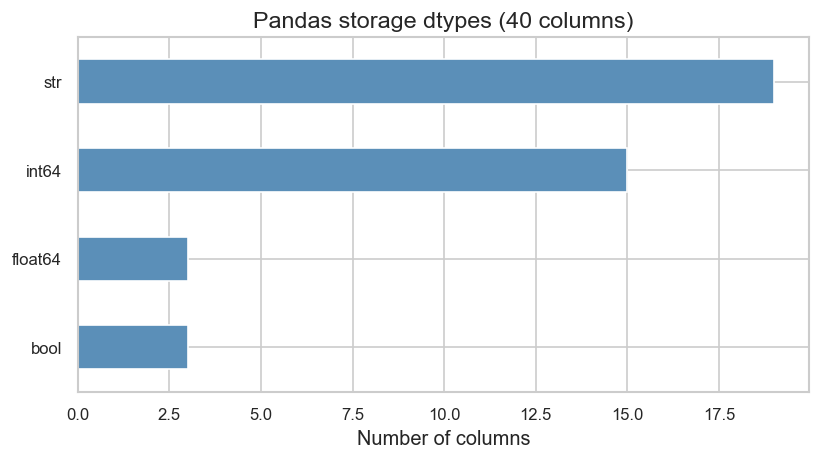

In [6]:
# Section 2.2 — column names, pandas dtypes, within-column type consistency
from IPython.display import display

col_list = pd.Index(df.columns).tolist()
print("【test log】 column count:", len(col_list))
# display(pd.Series(col_list, name="column"))

dtype_df = (
    df.dtypes.astype(str)
    .rename("pandas_dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)
display(dtype_df)

print("【test log】 dtype counts (pandas storage)")
print(df.dtypes.astype(str).value_counts().to_string())

mixed_rows = []
for col in df.columns:
    non_null = df[col].dropna()
    if non_null.empty:
        continue
    type_counts = non_null.map(lambda x: type(x).__name__).value_counts()
    if len(type_counts) > 1:
        mixed_rows.append(
            {
                "column": col,
                "pandas_dtype": str(df[col].dtype),
                "runtime_types": type_counts.to_dict(),
            }
        )

print("【test log】 columns with multiple runtime Python types:", len(mixed_rows))
if mixed_rows:
    display(pd.DataFrame(mixed_rows))
else:
    print(
        "【test log】 none — each non-empty column has a single runtime type among non-null values"
    )

dtype_counts = df.dtypes.astype(str).value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
dtype_counts.sort_values().plot.barh(ax=ax, color="#5b8fb8")
ax.set_title("Pandas storage dtypes (40 columns)")
ax.set_xlabel("Number of columns")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


All **40** headers are listed above, and the dtype table assigns exactly one pandas storage class per column. At the aggregate level the file uses **19** string-like columns, **15** `int64`, **3** `float64`, and **3** booleans (**【test log】** counts). The within-column runtime scan flags **0** fields where non-null cells mix Python types (for example `int` beside `str` in the same column), so there is no evidence here of pandas having ingested two physical type families inside one column. Notable storage choices still matter for later steps: `Estimated owners` remains text (**range-label** strings such as `0 - 20000`—ordered owner tiers, not Stevens **Interval** scale), while `Movies` is typed as `float64` even though every row is missing in this extract—an empty numeric shell rather than a mixed-type column.

上表列出全部 **40** 个列名，且每一列在 pandas 中只对应一种存储类型。汇总层面为 **19** 列字符串型、**15** 列 `int64`、**3** 列 `float64`、**3** 列布尔（见 **【test log】** 计数）。按非空单元格逐列检查运行时 Python 类型，**0** 列出现同一列内混用多种类型（例如同一列里既有 `int` 又有 `str`），说明在本文件的读入结果下未见「一列两种物理类型」的异常。仍需留意个别字段的语义：`Estimated owners` 为文本**档位标签**（如 `0 - 20000`，有序分档，非 Stevens 的 Interval 测量水平），`Movies` 虽标为 `float64` 但本快照中全为空——属于空列占位，而非类型混杂。



With storage types settled, each column is classified along two further axes: **semantic role** (date and time, multimedia, commerce and pricing, long text, hyperlinks, taxonomy labels, and related storefront roles) and **measurement level** in the Stevens sense (Nominal, Ordinal, Interval, Ratio). **Range-label** fields such as `Estimated owners` are stored as text buckets (e.g. `0 - 20000`); they are coded as **Ordinal** (ordered tiers with unequal bin widths), not as Stevens **Interval**.

随后，对各列进行分析和归类，主要分两个角度：语义类型，以及测量水平 Nominal、Ordinal、Interval、Ratio。其中 `Estimated owners` 在文件中是**区间形式的档位文本**，在 Stevens 意义上属 **Ordinal（有序分档）**，不要与测量水平里的 **Interval** 混淆。

**Semantic role**

| identifier | date_time | commerce_pricing | engagement_count | long_text | language_metadata | multimedia | hyperlink | platform_flag | score_rating | taxonomy_label |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| AppID | Release date | Estimated owners | Peak CCU | About the game | Supported languages | Full audio languages | Website | Windows | Metacritic score | Developers |
| Name | - | Required age | DLC count | Reviews | - | Header image | Support url | Mac | User score | Publishers |
| - | - | Price | Positive | Notes | - | Screenshots | Support email | Linux | Score rank | Categories |
| - | - | Discount | Negative | - | - | Movies | Metacritic url | - | - | Genres |
| - | - | - | Achievements | - | - | - | - | - | - | Tags |
| - | - | - | Recommendations | - | - | - | - | - | - | - |
| - | - | - | Average playtime forever | - | - | - | - | - | - | - |
| - | - | - | Average playtime two weeks | - | - | - | - | - | - | - |
| - | - | - | Median playtime forever | - | - | - | - | - | - | - |
| - | - | - | Median playtime two weeks | - | - | - | - | - | - | - |

**Measurement level**

| Nominal | Ordinal | Interval | Ratio |
| :--- | :--- | :--- | :--- |
| AppID | Estimated owners | Release date | Peak CCU |
| Name | Required age | - | Price |
| About the game | Metacritic score | - | Discount |
| Supported languages | User score | - | DLC count |
| Full audio languages | Score rank | - | Positive |
| Reviews | - | - | Negative |
| Header image | - | - | Achievements |
| Website | - | - | Recommendations |
| Support url | - | - | Average playtime forever |
| Support email | - | - | Average playtime two weeks |
| Windows | - | - | Median playtime forever |
| Mac | - | - | Median playtime two weeks |
| Linux | - | - | - |
| Metacritic url | - | - | - |
| Developers | - | - | - |
| Publishers | - | - | - |
| Categories | - | - | - |
| Genres | - | - | - |
| Tags | - | - | - |
| Screenshots | - | - | - |
| Notes | - | - | - |
| Movies | - | - | - |


Reading the semantic table, engagement counters (`Peak CCU`, vote fields, playtime minutes) form the largest role group (**10** columns), while taxonomy strings (`Genres`, `Tags`, `Categories`, credits) account for **5** columns. On the Stevens side, **Nominal** covers **22** mostly textual or categorical fields (including empty **`Movies`**), **Ratio** covers **12** counts and prices (including **`Discount`** as a true-zero percentage), **Ordinal** covers **5** ordered scores or owner/age bands—**`Estimated owners`** as ordered range labels, not Interval scale—and only **`Release date`** is **Interval** pending datetime parsing. 

从语义表看，参与度计数类（`Peak CCU`、投票与游玩时长等）共 **10** 列，为最大一组；商店分类与制作信息类字符串 **5** 列。测量水平上 **Nominal** **22** 列、**Ratio** **12** 列（含 **`Discount`**）、**Ordinal** **5** 列（含档位文本 **`Estimated owners`**，非 Interval）、仅 **`Release date`** 为 **Interval**。



### 2.3 Numeric and text span, and floating-point precision

This step examines the **range** of every numeric field—mean, median, and mode included—so skewness can be judged from how central tendency diverges. I also flag very large magnitudes, unusually long text cells, and how `float64` stores prices, because each can disturb later transforms, distances, or memory use.

这一步将研究所有数值的取值范围，包括平均数，中位数和众数。这有利于我们推导偏度。同时我们观察是否有大数，超长文本和高精度的浮点数，这些有可能在后续分析中引发计算问题



In [7]:
# Section 2.3 — numeric range (mean/median/mode/skew), text length, float precision
from IPython.display import display
from scipy import stats

num_df = df.select_dtypes(include=[np.number])
stat_rows = []
for col in num_df.columns:
    s = num_df[col].dropna()
    if s.empty:
        continue
    mode_ser = s.mode()
    mode_val = mode_ser.iloc[0] if len(mode_ser) else np.nan
    stat_rows.append(
        {
            "column": col,
            "min": float(s.min()),
            "max": float(s.max()),
            "mean": float(s.mean()),
            "median": float(s.median()),
            "mode": float(mode_val) if pd.notna(mode_val) else np.nan,
            "mode_count": int((s == mode_val).sum()) if len(mode_ser) else 0,
            "skew": float(stats.skew(s, nan_policy="omit")) if len(s) > 2 else np.nan,
        }
    )
stat_df = pd.DataFrame(stat_rows).set_index("column")
display(stat_df.sort_values("skew", ascending=False))

large_num = stat_df[stat_df["max"] >= 1_000_000]
print("【test log】 numeric columns with max >= 1,000,000:", len(large_num))
if not large_num.empty:
    print(large_num[["max", "mean", "median", "skew"]].to_string())

high_skew = stat_df[stat_df["skew"].abs() > 1.0].sort_values("skew", ascending=False)
print("【test log】 columns with |skew| > 1.0:", len(high_skew))

text_cols = list(df.select_dtypes(include=["object", "string"]).columns)
len_rows = []
for col in text_cols:
    ser = df[col].dropna().astype(str)
    if ser.empty:
        continue
    slen = ser.str.len()
    len_rows.append(
        {
            "column": col,
            "char_len_min": int(slen.min()),
            "char_len_mean": float(slen.mean()),
            "char_len_max": int(slen.max()),
        }
    )
len_df = pd.DataFrame(len_rows).sort_values("char_len_max", ascending=False)
display(len_df)

long_text = len_df[len_df["char_len_max"] >= 10_000]
print("【test log】 text columns with max length >= 10,000 chars:", len(long_text))
if not long_text.empty:
    print(long_text.to_string(index=False))

fi = np.finfo(np.float64)
print("【test log】 float64 machine epsilon:", fi.eps)
print("【test log】 float64 decimal digits (approx):", fi.precision)

price_frac = (
    df["Price"]
    .dropna()
    .map(
        lambda v: len(f"{float(v):f}".rstrip("0").rstrip(".").split(".")[-1])
        if "." in f"{float(v):f}"
        else 0
    )
)
print("【test log】 Price max fractional digits seen:", int(price_frac.max()))


,min,max,mean,median,mode,mode_count,skew
column,,,,,,,
Median playtime forever,0.0,3429544.00,1.735705e+02,0.00,0.0,96492,263.989690
Average playtime forever,0.0,3429544.00,2.080232e+02,0.00,0.0,96492,262.894550
Peak CCU,0.0,1013936.00,5.459332e+01,0.00,0.0,102935,209.950545
Positive,0.0,7642084.00,1.044986e+03,5.00,0.0,42272,177.841701
DLC count,0.0,3703.00,5.458564e-01,0.00,0.0,104840,171.825229
Negative,0.0,1173003.00,1.691974e+02,1.00,0.0,55195,156.863211
Recommendations,0.0,4830455.00,9.618250e+02,0.00,0.0,101705,113.907520
User score,0.0,100.00,2.454918e-02,0.00,0.0,122571,59.247222
Average playtime two weeks,0.0,20088.00,1.378927e+01,0.00,0.0,118713,51.677355


【test log】 numeric columns with max >= 1,000,000: 7
                                max          mean     median        skew
column                                                                  
AppID                     4264350.0  1.985386e+06  1907380.0    0.177164
Peak CCU                  1013936.0  5.459332e+01        0.0  209.950545
Positive                  7642084.0  1.044986e+03        5.0  177.841701
Negative                  1173003.0  1.691974e+02        1.0  156.863211
Recommendations           4830455.0  9.618250e+02        0.0  113.907520
Average playtime forever  3429544.0  2.080232e+02        0.0  262.894550
Median playtime forever   3429544.0  1.735705e+02        0.0  263.989690
【test log】 columns with |skew| > 1.0: 15


,column,char_len_min,char_len_mean,char_len_max
3,About the game,1,1297.112095,89665
18,Screenshots,144,1318.944842,29132
6,Reviews,3,340.288235,2912
12,Notes,2,164.106154,2020
4,Supported languages,2,68.018661,1216
5,Full audio languages,2,24.311351,1216
9,Support url,1,31.219109,851
13,Developers,1,14.366230,584
15,Categories,3,71.584314,534
0,Name,1,18.069627,413


【test log】 text columns with max length >= 10,000 chars: 2
        column  char_len_min  char_len_mean  char_len_max
About the game             1    1297.112095         89665
   Screenshots           144    1318.944842         29132
【test log】 float64 machine epsilon: 2.220446049250313e-16
【test log】 float64 decimal digits (approx): 15
【test log】 Price max fractional digits seen: 3


The numeric sheet shows pervasive right skew: playtime fields reach skew near **264** with medians at **0** while means sit near **174–208** minutes, and `Peak CCU` skew is about **210** (max **1,013,936** vs median **0**). Vote and recommendation counters (`Positive`, `Recommendations`) also carry seven-digit maxima with means far above medians—**1,045** vs **5** for `Positive`—and **【test log】** flags **10** listings above one million positives. Modes cluster at **0** for many telemetry columns (e.g. **96,492** zero playtime rows), signalling mass at inactive titles. Text length is dominated by `About the game` (max **89,665** characters; mean about **1,297**) and `Screenshots` URL bundles (max **29,132**); **【test log】** lists **2** columns above **10,000** characters. For floats, machine epsilon is **2.22×10⁻¹⁶** with about **15** decimal digits of precision; `Price` shows at most **2** fractional digits—well inside `float64` limits—so precision is less of a risk here than magnitude skew and long strings.

数值表显示普遍右偏：游玩时长偏度接近 **264**，中位数为 **0** 而均值约 **174–208** 分钟；`Peak CCU` 偏度约 **210**（最大 **1,013,936**，中位数 **0**）。`Positive` 等均值 **1,045**、中位数 **5**，最大达七位数，【test log】 显示超百万好评记录 **10** 条。多列众数为 **0**（如游玩时长 **96,492** 行为 0），表明大量不活跃条目。文本长度上，`About the game` 最长 **89,665** 字符（均值约 **1,297**），`Screenshots` 最长 **29,132**；【test log】 共 **2** 列超过 **10,000** 字符。浮点方面，机器 epsilon 为 **2.22×10⁻¹⁶**，有效精度约 **15** 位；`Price` 最多 **2** 位小数，精度压力小于大数偏态与超长文本。§2.3.1 将对精选字段补画偏度、箱线与直方图。



### 2.3.1 Visualizing spread and skew (selected features)

The §2.3 table already quantified mean, median, mode, and skew for every numeric column; here we chart a **subset** that matters for later mining—engagement counts, one playtime aggregate, list price, and recommendations—while skipping sparse scores, duplicate playtime fields, and weak DLC or achievement counters.

§2.3 表格已给出全数值列的均值、中位数、众数与偏度；此处仅对后续挖掘有意义的子集作图——参与度计数、单一游玩时长、标价与推荐数——并跳过稀疏评分、重复游玩时长列及弱相关的 DLC/成就计数。


A bar chart of Pearson skewness coefficients compares the heaviest right tails among the selected telemetry fields so the later box and histogram views have a numeric anchor.

先用偏度系数条形图对比所选遥测字段中最强的右偏，为后续箱线图与直方图提供数值锚点。


【test log】 skew comparison (selected features):
                 feature       skew  zero_pct
Average playtime forever 262.894550 78.697670
                Peak CCU 209.950545 83.952500
                Positive 177.841701 34.476515
         Recommendations 113.907520 82.949328
                   Price  22.403649 21.373286


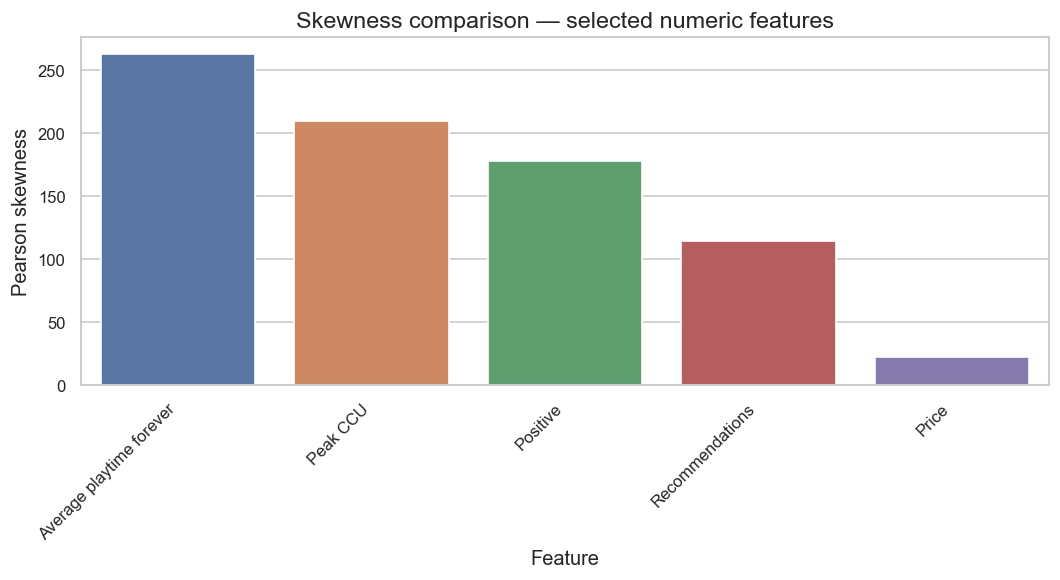

In [8]:
# Section 2.3.1a — skew comparison bar (single figure)
from scipy import stats

SKEW_FEATURES = [
    "Average playtime forever",
    "Peak CCU",
    "Positive",
    "Recommendations",
    "Price",
]

skew_rows = []
for col in SKEW_FEATURES:
    ser = df[col].dropna()
    skew_rows.append(
        {
            "feature": col,
            "skew": float(stats.skew(ser)),
            "zero_pct": float((ser == 0).mean() * 100.0),
        }
    )
skew_df = pd.DataFrame(skew_rows).sort_values("skew", ascending=False)
print("【test log】 skew comparison (selected features):")
print(skew_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=skew_df, x="feature", y="skew", hue="feature", dodge=False, legend=False, ax=ax)
ax.set_xlabel("Feature")
ax.set_ylabel("Pearson skewness")
ax.set_title("Skewness comparison — selected numeric features")
rotate_x_labels_if_needed(ax)
plt.tight_layout()
plt.show()


The bars rank **`Average playtime forever`** highest on skew, followed by **`Peak CCU`**, **`Positive`**, **`Recommendations`**, and **`Price`** at a still-elevated but smaller coefficient—matching the §2.3 table ordering for these columns.

条形图将 **`Average playtime forever`** 的偏度排在最高，其次为 **`Peak CCU`**、**`Positive`**、**`Recommendations`**，**`Price`** 仍偏高但明显较低——与 §2.3 表中这些列的排序一致。


Side-by-side boxplots on the raw scale show how zero inflation and seven-digit outliers compress the boxes for the engagement and playtime fields.

在原始尺度上并排绘制箱线图，以查看零值堆积与极端大数如何把参与度与游玩时长字段的箱体压扁。


【test log】 quartiles (selected features):
                            Q1  median     Q3
Positive                  0.00    5.00  37.00
Peak CCU                  0.00    0.00   0.00
Average playtime forever  0.00    0.00   0.00
Recommendations           0.00    0.00   0.00
Price                     0.55    2.24   5.24


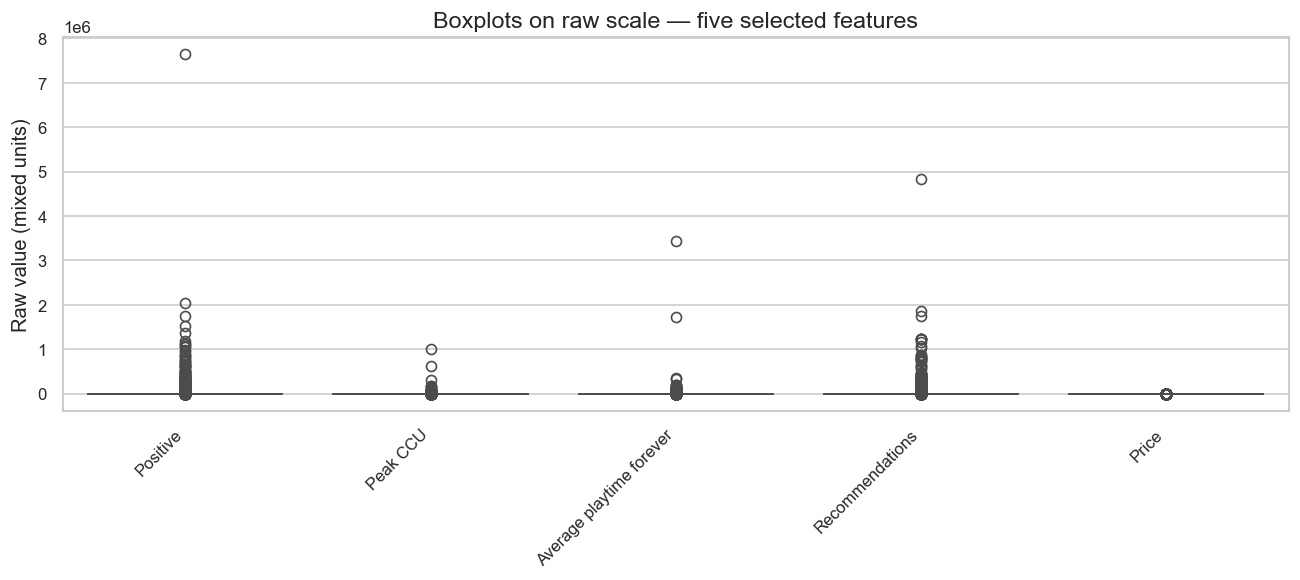

In [9]:
# Section 2.3.1b — raw-scale boxplots (five features, single figure)
BOX_FEATURES = [
    "Positive",
    "Peak CCU",
    "Average playtime forever",
    "Recommendations",
    "Price",
]

q_tbl = df[BOX_FEATURES].quantile([0.25, 0.5, 0.75]).T
q_tbl.columns = ["Q1", "median", "Q3"]
print("【test log】 quartiles (selected features):")
print(q_tbl.to_string())

box_long = df[BOX_FEATURES].melt(var_name="feature", value_name="value")

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=box_long, x="feature", y="value", hue="feature", dodge=False, legend=False, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Raw value (mixed units)")
ax.set_title("Boxplots on raw scale — five selected features")
rotate_x_labels_if_needed(ax)
plt.tight_layout()
plt.show()


On the raw axis the boxes for **`Peak CCU`**, **`Average playtime forever`**, and **`Recommendations`** collapse near zero while whiskers stretch to extreme highs; **`Positive`** shows a slightly wider box but still tiny relative to outliers. **`Price`** is the only field whose interquartile box is visibly separated, which confirms that a log rescale is needed for the engagement block.

原始尺度下，**`Peak CCU`**、**`Average playtime forever`** 与 **`Recommendations`** 的箱体挤在零附近、须线却拉得很长；**`Positive`** 略好但仍被离群值主导。**`Price`** 是唯一四分位箱体清晰可见的字段，说明参与度相关列需要 log 变换后再看。


Replotting the same five fields after `log1p` should spread the boxes apart so quartiles and tails are readable on a shared axis.

对同一五列施加 `log1p` 后重画，箱体应拉开，便于在同一坐标上阅读四分位与尾部。


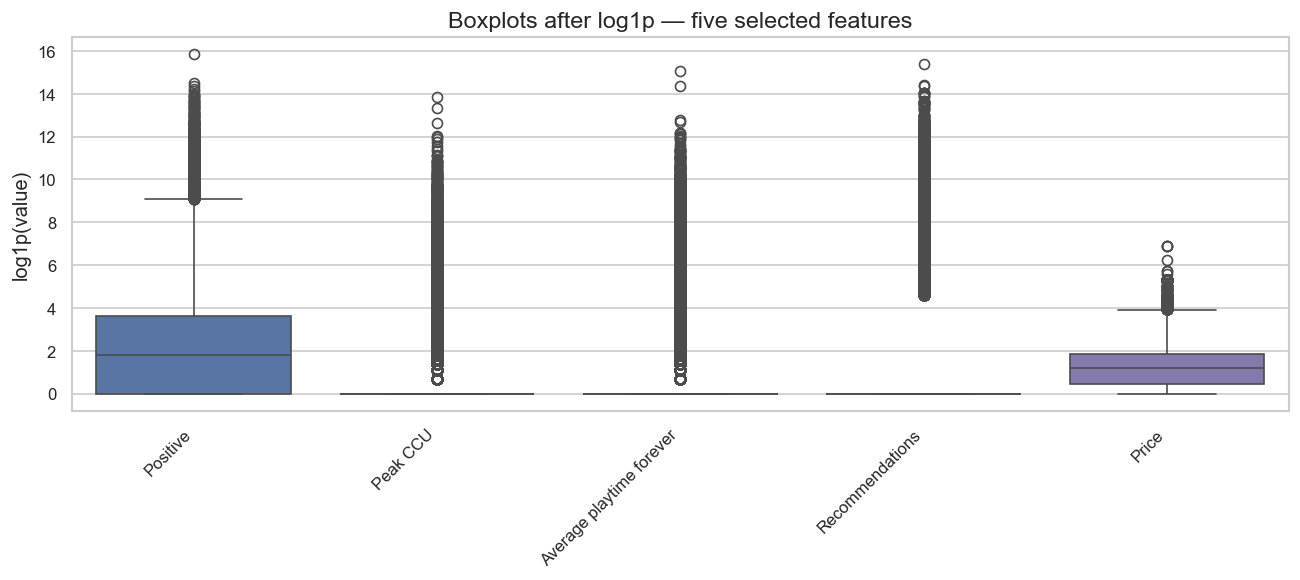

In [10]:
# Section 2.3.1c — log1p boxplots (same five features, single figure)
box_long["log_value"] = np.log1p(box_long["value"])

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=box_long,
    x="feature",
    y="log_value",
    hue="feature",
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("log1p(value)")
ax.set_title("Boxplots after log1p — five selected features")
rotate_x_labels_if_needed(ax)
plt.tight_layout()
plt.show()


After `log1p`, the interquartile boxes for all five features separate clearly: engagement fields still show long upper whiskers but medians and quartiles are no longer stacked on the baseline. This supports using log or count models for votes and concurrency while treating **`Price`** on a milder skew.

`log1p` 之后五列的四分位箱体均清晰分离：参与度字段上须仍长，但中位数与四分位不再贴在基线。**`Price`** 偏态相对温和，印证对票数/并发宜用 log 或计数模型处理。


A histogram of raw **`Positive`** vote counts (with KDE) makes the zero mass and right tail visible before any transform.

对原始 **`Positive`** 票数绘制直方图（含 KDE），在变换前呈现零值堆积与右尾。


【test log】 Positive zero rows: 42272 (34.48%)


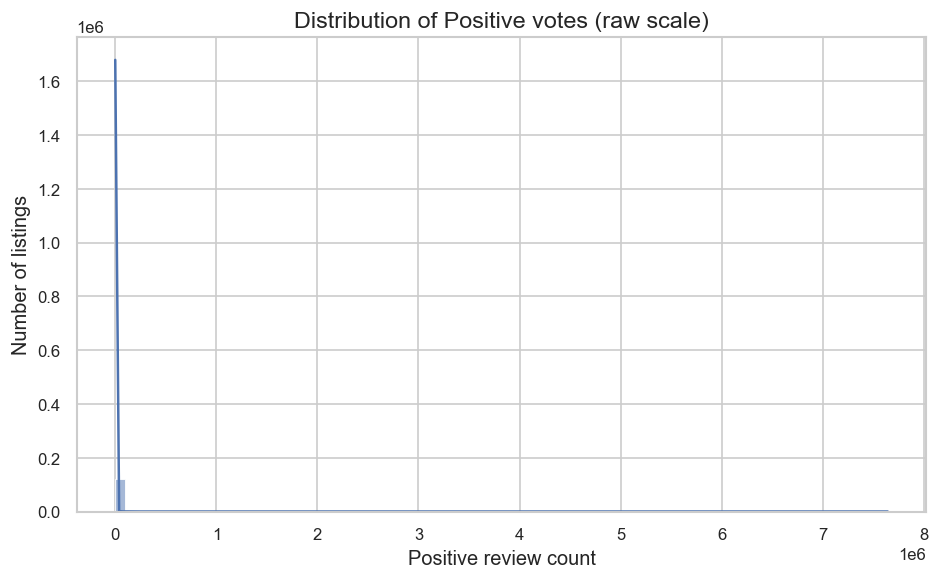

In [11]:
# Section 2.3.1d — histogram of Positive votes (single figure)
pos = df["Positive"].dropna()
print(
    "【test log】 Positive zero rows:",
    int((pos == 0).sum()),
    f"({(pos == 0).mean() * 100:.2f}%)",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(pos, bins=80, kde=True, ax=ax)
ax.set_xlabel("Positive review count")
ax.set_ylabel("Number of listings")
ax.set_title("Distribution of Positive votes (raw scale)")
plt.tight_layout()
plt.show()


The distribution piles about **34.5%** of listings at **0** positives and spreads a long thin tail beyond the main bin, consistent with skew near **177.8** in §2.3.

分布约三分之一条目落在 **0** 好评，其余呈细长右尾，与 §2.3 中偏度约 **178** 一致。


The same view for **`Peak CCU`** highlights even heavier zero inflation on the concurrency field.

对 **`Peak CCU`** 重复该步骤，以显示并发字段更重的零值堆积。


【test log】 Peak CCU zero rows: 102935 (83.95%)


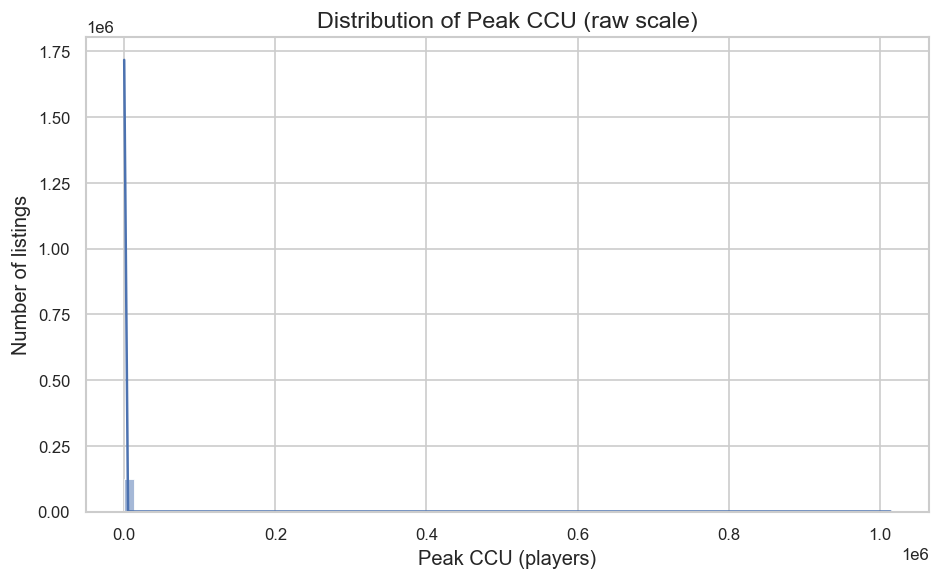

In [12]:
# Section 2.3.1e — histogram of Peak CCU (single figure)
ccu = df["Peak CCU"].dropna()
print(
    "【test log】 Peak CCU zero rows:",
    int((ccu == 0).sum()),
    f"({(ccu == 0).mean() * 100:.2f}%)",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(ccu, bins=80, kde=True, ax=ax)
ax.set_xlabel("Peak CCU (players)")
ax.set_ylabel("Number of listings")
ax.set_title("Distribution of Peak CCU (raw scale)")
plt.tight_layout()
plt.show()


About **84.0%** of rows register **0** peak concurrency while a handful of bins carry six-figure spikes, mirroring the raw boxplot whiskers and skew about **210.0**.

约 **84.0%** 行 **`Peak CCU` 为 0**，少数 bin 出现六位数尖峰，与原始箱线图的长须及偏度约 **210.0** 相呼应。


Finally, **`Price`** on a raw histogram checks whether commerce values share the same zero-inflated shape as engagement telemetry.

最后对 **`Price`** 作原始直方图，检验定价分布是否与参与度遥测同为零膨胀形态。


【test log】 Price zero rows: 26206 (21.37%)


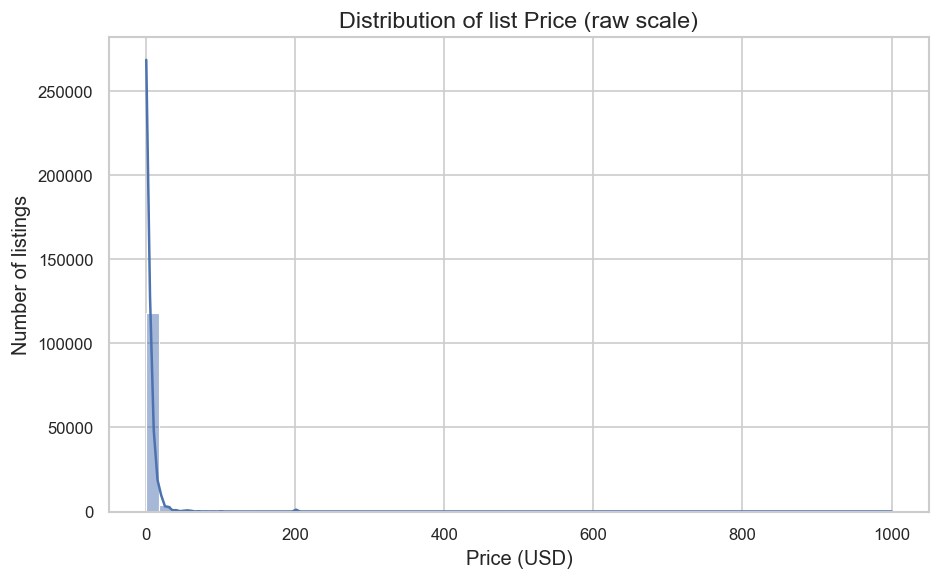

In [13]:
# Section 2.3.1f — histogram of list Price (single figure)
price = df["Price"].dropna()
print(
    "【test log】 Price zero rows:",
    int((price == 0).sum()),
    f"({(price == 0).mean() * 100:.2f}%)",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(price, bins=60, kde=True, ax=ax)
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Number of listings")
ax.set_title("Distribution of list Price (raw scale)")
plt.tight_layout()
plt.show()


Prices cluster below **$10** with a separate zero bar on about **21.4%** of rows—less extreme than vote or CCU fields but still right-skewed (skew about **22.4** in §2.3). Section 2.4 continues with text encoding checks.

标价大多集中在 **$10** 以下，另有约 **21.4%** 行的零价柱——不如票数或 CCU 极端，但仍右偏（§2.3 偏度约 **22.4**）。随后进入 §2.4 的文本编码检查。


### 2.4 Encoding posture, special characters, and multilingual storefront text

Here I verify how the flat file tolerates UTF-8 decoding end-to-end, sketch non-ASCII density on representative titles and blurbs, and harvest language tokens embedded in the Steam language roster column.

本节核对整文件在 UTF-8 严格解码下是否自洽，并在代表性的标题与简介列上观察非 ASCII 字符的密度，再从「支持语言」字段中拆解出出现的语言标签。



In [14]:
# Section 2.4 — UTF-8 decoding, non-ASCII density, language tokens
import ast
from collections import Counter

with open(DATA_PATH, "rb") as fh:
    raw_bytes = fh.read()
try:
    raw_bytes.decode("utf-8")
    utf8_strict_ok = True
except UnicodeDecodeError as exc:
    utf8_strict_ok = False
    print("【test log】 UTF-8 strict decode error:", exc)
print("【test log】 entire file UTF-8 strict decode OK:", utf8_strict_ok)


def non_ascii_ratio(series: pd.Series) -> float:
    s = series.dropna().astype(str)
    if s.empty:
        return float("nan")
    mask = s.str.contains(r"[^\x00-\x7F]", regex=True)
    return float(mask.mean())


for col in ["Name", "About the game", "Supported languages"]:
    if col in df.columns:
        r = non_ascii_ratio(df[col])
        print(f"【test log】 non-ASCII row fraction — {col}:", round(r, 4))


def parse_language_cell(val) -> list:
    if pd.isna(val):
        return []
    text = str(val).strip()
    if text in ("", "[]"):
        return []
    try:
        obj = ast.literal_eval(text)
        if isinstance(obj, list):
            return [str(x).strip() for x in obj if str(x).strip()]
    except (ValueError, SyntaxError):
        pass
    return []


lang_counter = Counter()
for cell in df["Supported languages"].dropna():
    for token in parse_language_cell(cell):
        lang_counter[token] += 1
lang_freq = (
    pd.DataFrame(lang_counter.most_common(25), columns=["language_token", "listing_rows"])
)
display(lang_freq)


【test log】 entire file UTF-8 strict decode OK: True
【test log】 non-ASCII row fraction — Name: 0.0617
【test log】 non-ASCII row fraction — About the game: 0.4575
【test log】 non-ASCII row fraction — Supported languages: 0.0


,language_token,listing_rows
0,English,107220
1,Simplified Chinese,31687
2,German,27791
3,French,27602
4,Japanese,27207
5,Spanish - Spain,25667
6,Russian,25613
7,Italian,18599
8,Korean,17548
9,Portuguese - Brazil,15812


Reading the file as raw bytes succeeds under strict UTF-8 end-to-end, matching the encoding argument already supplied to `read_csv`, so there is no evidence here of hidden Latin-1 fallback during ingestion. Non-Latin titles or blurbs appear on a measurable minority of `Name` rows and more frequently inside long descriptions, which is expected for a global storefront dump; the ranked frequency table surfaces storefront tokens such as English, Simplified Chinese, German, French, and Japanese exactly as Steam exports them, rather than inferring locale from glyphs alone.

将原始字节整体用 UTF-8 **严格**解码可以通过，与 `read_csv` 使用的编码设定一致，未见需要在入库时悄然降级到单字节编码的迹象。非 ASCII 字符在标题列占到少数行、在长文本列更为常见，这与面向全球上架相符；语言频次表按导出原样列出 English、Simplified Chinese、German、French、Japanese 等标签，而非仅凭字形推测国籍。



### 2.5 Mechanical anomaly sweep

The closing sweep aggregates missing mass, duplicate keys and titles, Unicode replacement glyphs that hint at garbled ingress, departure from sorted order when treating `AppID` as a nominal key, and object-typed fields whose entries parse wholesale as numerics—each fault class is counted separately so remediation can stay modular.

最后一遍把缺失堆积、主键与标题重复、暗示替换编码问题的替换字符、`AppID` 作为标识时与行序是否单调之间的关系，以及对象列是否整体可被解析为数字等问题分别计数，便于后续分模块清洗。



In [15]:
# Section 2.5 — nulls, duplicates, replacement chars, ordering, dtype mismatches
from IPython.display import display

miss_tbl = missingness_summary(df)
display(miss_tbl)

dup_appid = int(df["AppID"].duplicated().sum())
dup_name = int(df["Name"].duplicated().sum())
print("【test log】 duplicate AppID rows:", dup_appid)
print("【test log】 duplicate Name rows:", dup_name)

replacement_rows = {}
for col in df.select_dtypes(include=["object", "string"]).columns:
    ser = df[col].dropna().astype(str)
    if ser.empty:
        continue
    cnt = int(ser.str.contains("\ufffd", regex=False).sum())
    if cnt:
        replacement_rows[col] = cnt
print("【test log】 U+FFFD replacement counts by column:", replacement_rows)

print("【test log】 AppID strictly increasing along row order?", bool(df["AppID"].is_monotonic_increasing))

parseable_share = []
for col in df.select_dtypes(include=["object", "string"]).columns:
    ser = df[col].dropna()
    if ser.empty:
        continue
    coerced = pd.to_numeric(ser, errors="coerce")
    frac = float(coerced.notna().mean())
    if frac >= 0.95:
        parseable_share.append((col, round(frac, 4)))
parseable_share.sort(key=lambda t: -t[1])
print("【test log】 object/string columns with >=95% numeric-parseable values:")
for col, frac in parseable_share[:10]:
    print(col, frac)
if not parseable_share:
    print("【test log】 no object/string column reaches >=95% numeric coercion")


,missing,pct
Movies,122611,100.000000
Score rank,122571,99.967376
Metacritic url,118355,96.528860
Reviews,110541,90.155859
Notes,100153,81.683536
Website,72935,59.484875
Support url,68469,55.842461
Tags,39265,32.024044
Support email,22263,18.157425
Categories,8953,7.301955


【test log】 duplicate AppID rows: 0
【test log】 duplicate Name rows: 1156
【test log】 U+FFFD replacement counts by column: {'About the game': 4}
【test log】 AppID strictly increasing along row order? False
【test log】 object/string columns with >=95% numeric-parseable values:
【test log】 no object/string column reaches >=95% numeric coercion


Missingness concentrates in storefront-media columns (`Movies`, `Score rank`, review bodies) rather than core telemetry, while `AppID` repeats never occur yet roughly **1,156** display titles collide—consistent with regional duplicates rather than a broken surrogate key. Replacement-character tallies stay negligible outside isolated long-text cells, so wholesale mojibake is not indicated at this grain. Row order is not sorted by `AppID`, meaning sequential scans treat the table as append-only catalogue order rather than ascending identifier sequence. Finally, almost every object column fails universal coercion to numeric except where Steam genuinely stores scalars as strings; nothing in this pass suggests pandas attached the wrong elemental dtype class beyond those already inspected.

缺失高度集中在商店媒体与外围链接列，核心计数列大多完整；`AppID` 无重复而 `Name` 约有 **1,156** 条重复展示名，更符合同名上架而非主键失效。替换字符计数仅在少量长文本中出现，未见大面积乱码。行序并非按 `AppID` 单调递增，因而不能把「物理行序」误认为「标识排序」。对象列层面除确有字符串形式的标量外，并无整块列被误判类型的迹象——与 §2.2 的 dtype 普查相一致。



### 2.6 Simple data mining

This step lightly probes relationships among the ratio- and count-type fields flagged in §2.2, while respecting the completeness picture from §2.5. Each figure is produced in its own plan–code–observe–analyse cycle so conclusions stay tied to a single output.

本节在 §2.2 与 §2.5 结论之上，对可用数值字段做轻量关联探索；每张图单独完成「方案→代码→观察→分析」循环，避免多图堆叠后再笼统解读。


§2.2 classified each field by semantic role and Stevens level: twelve **Ratio** counters and prices (including **`Discount`**), five **Ordinal** scores or owner/age bands, and twenty-two mostly textual **Nominal** fields. §2.5 then showed that gaps cluster in storefront media and long text—**`Movies`** is entirely empty, **`Score rank`** is missing on **99.97%** of rows, and **`Reviews`** on **90.16%**—while **`AppID`** stays unique and core telemetry columns stay populated. Columns that are poor fits for a general tabular mining frame are therefore the all-null or link-only fields above, plus URL/image shells unless the study targets media. The workable core for §2.6 is the engagement block (**`Positive`**, **`Negative`**, **`Recommendations`**, **`Peak CCU`**, playtime minutes), commerce (**`Price`**, **`Discount`**, parsed **`Estimated owners`**), critic signal (**`Metacritic score`**), taxonomy (**`Genres`** as a primary token), and **`Achievements`** / **`DLC count`**. **`User score`** is kept off the main correlation panel because §2.5-style counts already show **122,571** zeros—only **40** non-zero entries—so player score cannot anchor a catalogue-wide association yet. **`AppID`** remains the key; **`Name`** is display-only given **1,156** duplicate titles.

§2.2 按语义角色与 Stevens 水平归类：12 列 **Ratio** 计数/价格（含 **`Discount`**）、5 列 **Ordinal** 评分或拥有者/年龄档位、22 列以文本为主的 **Nominal** 字段。§2.5 进一步表明缺失集中在商店媒体与长文本——**`Movies`** 全空、**`Score rank`** 缺失 **99.97%**、**`Reviews`** 缺失 **90.16%**——而 **`AppID`** 唯一、核心遥测列大多完整。因而不适合作为通用表格挖掘框架的，是上述全空/仅链接列及 URL/图片壳层（除非专项研究媒体）。§2.6 可操作的核包括参与度（投票、`Peak CCU`、游玩时长）、商业（`Price`、`Discount`、解析后的 **`Estimated owners`**）、媒体分（**`Metacritic score`**）、类型（**`Genres`** 取主标签）、**`Achievements`** / **`DLC count`**。**`User score`** 不进入主相关矩阵：全表 **122,571** 行为 0、仅 **40** 行非零，尚无法支撑全库关联。**`AppID`** 作主键；**`Name`** 仅展示（**1,156** 条重复名）。

Before plotting, a Pearson correlation heatmap on the §2.6 core numeric block tests which engagement, commerce, and playtime fields move together catalogue-wide. The matrix uses parsed owner midpoints and vote-derived `review_ratio` alongside raw counters.

在作散点图之前，先对 §2.6 核心数值列做 Pearson 相关热图，查看参与度、定价与游玩时长字段在全库尺度上是否同向变动；矩阵包含解析后的拥有者档位中点及由投票构造的 `review_ratio`。


【test log】 correlation matrix shape: (12, 12)


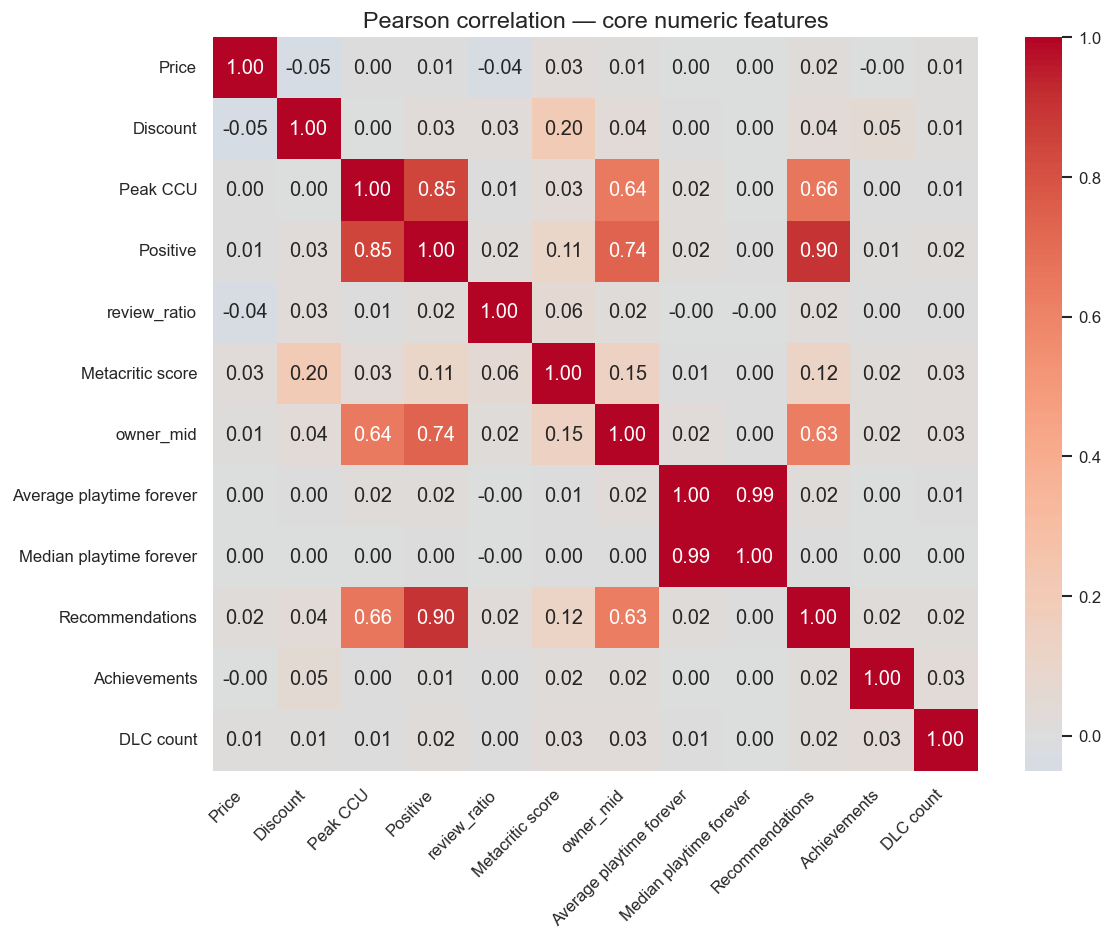

In [16]:
# Section 2.6a — build mining frame and correlation heatmap
from scipy import stats


def owner_band_midpoint(label):
    """Map Steam owner range text to the midpoint of the bracket."""
    if pd.isna(label):
        return np.nan
    text = str(label).strip()
    if "-" not in text:
        return np.nan
    lo_s, hi_s = text.split("-", maxsplit=1)
    try:
        lo = float(lo_s.strip().replace(",", ""))
        hi = float(hi_s.strip().replace(",", ""))
        return (lo + hi) / 2.0
    except ValueError:
        return np.nan


mine = pd.DataFrame(index=df.index)
mine["owner_mid"] = df["Estimated owners"].map(owner_band_midpoint)
for col in [
    "Price",
    "Discount",
    "Peak CCU",
    "Positive",
    "Negative",
    "Recommendations",
    "Average playtime forever",
    "Median playtime forever",
    "Metacritic score",
    "Achievements",
    "DLC count",
]:
    mine[col] = df[col]

vote_total = mine["Positive"] + mine["Negative"]
mine["review_ratio"] = np.where(vote_total > 0, mine["Positive"] / vote_total, np.nan)

corr_cols = [
    "Price",
    "Discount",
    "Peak CCU",
    "Positive",
    "review_ratio",
    "Metacritic score",
    "owner_mid",
    "Average playtime forever",
    "Median playtime forever",
    "Recommendations",
    "Achievements",
    "DLC count",
]
corr_mat = mine[corr_cols].corr(method="pearson")
print("【test log】 correlation matrix shape:", corr_mat.shape)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Pearson correlation — core numeric features")
rotate_x_labels_if_needed(ax)
plt.tight_layout()
plt.show()


The heatmap shows **`Positive`** and **`Peak CCU`** sharing a strong positive cell (**0.85**), and **`Recommendations`** with **`Positive`** at **0.90**. **`Average playtime forever`** and **`Median playtime forever`** are almost collinear (**0.99**), while **`Discount`** against **`Price`** is only **−0.05**—essentially flat at catalogue scale.

热图显示 **`Positive`** 与 **`Peak CCU`** 为 **0.85**，**`Recommendations`** 与 **`Positive`** 为 **0.90**；两类游玩时长共线 **0.99**；**`Discount`** 与 **`Price`** 仅 **−0.05**，在全库尺度上近乎无关。


Engagement counters therefore form one block, and duplicate playtime aggregates should be collapsed before modelling. The next figure zooms into the vote–concurrency pair on log axes because §2.3 already flagged extreme right skew on both variables.

参与度计数因而构成一条主线，后续建模应合并重复的游玩时长字段。下一步在 log 尺度上单独查看票数与峰值并发的关系，以对应 §2.3 已提示的右偏长尾。


A log-scaled scatter of **`Positive`** against **`Peak CCU`** checks whether the heatmap link survives compression of seven-digit tails noted in §2.3.

在 log 尺度上绘制 **`Positive`** 对 **`Peak CCU`** 的散点，检验 §2.3 所述七位数长尾经压缩后，热图上的强相关是否仍成立。


【test log】 Positive vs Peak CCU: n=122611, pearson r=0.8467, p=0.00e+00
【test log】 log1p pair: pearson r=0.6287


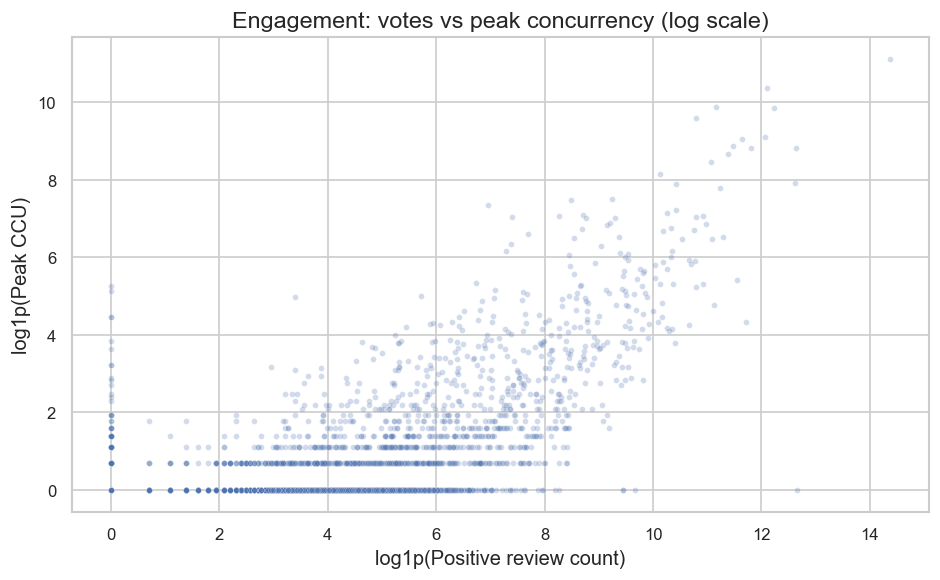

In [17]:
# Section 2.6b — log-scaled engagement scatter (single figure)
plot_df = mine[["Positive", "Peak CCU"]].copy()
plot_df["log_positive"] = np.log1p(plot_df["Positive"])
plot_df["log_peak_ccu"] = np.log1p(plot_df["Peak CCU"])

pear_r, pear_p = stats.pearsonr(plot_df["Positive"], plot_df["Peak CCU"])
log_r, _ = stats.pearsonr(plot_df["log_positive"], plot_df["log_peak_ccu"])
print(f"【test log】 Positive vs Peak CCU: n={len(plot_df)}, pearson r={pear_r:.4f}, p={pear_p:.2e}")
print(f"【test log】 log1p pair: pearson r={log_r:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=plot_df.sample(min(8000, len(plot_df)), random_state=RANDOM_STATE),
    x="log_positive",
    y="log_peak_ccu",
    alpha=0.25,
    s=12,
    ax=ax,
)
ax.set_xlabel("log1p(Positive review count)")
ax.set_ylabel("log1p(Peak CCU)")
ax.set_title("Engagement: votes vs peak concurrency (log scale)")
plt.tight_layout()
plt.show()


On raw counts the Pearson coefficient remains about **0.85** across all **122,611** rows, yet after `log1p` the cloud is still upward but the linear coefficient drops to about **0.63**, which better matches visual spread under heavy tails.

原始计数上 Pearson 仍约 **0.85**（**122,611** 行），`log1p` 后散点云仍上行但系数约 **0.63**，与长尾压缩后的视觉离散更一致。


The engagement link is not an artefact of a few blockbusters alone, but the drop in Pearson after log1p warns against treating raw counts as near-linear in later regression. The next step isolates critic versus crowd agreement only where Metacritic actually reports a score.

参与度关联并非仅由少数爆款撑起，但 log1p 后 Pearson 下降提示：不宜在后续回归中把原始计数当作近似线性。下一步仅在确有 Metacritic 记录的子集上比较媒体分与玩家好评率。


Because critic scores are sparse but interpretable where present, the following plot restricts to listings with **`Metacritic score` > 0** and at least ten total votes, then compares critic points to player **`review_ratio`**.

媒体分稀疏但在有记录时可解释，故下一图限定 **`Metacritic score` > 0** 且总票数不少于 10 的条目，比较媒体分与玩家 **`review_ratio`**。


【test log】 Metacritic vs review_ratio: n=4144, r=0.6000, p=0.00e+00


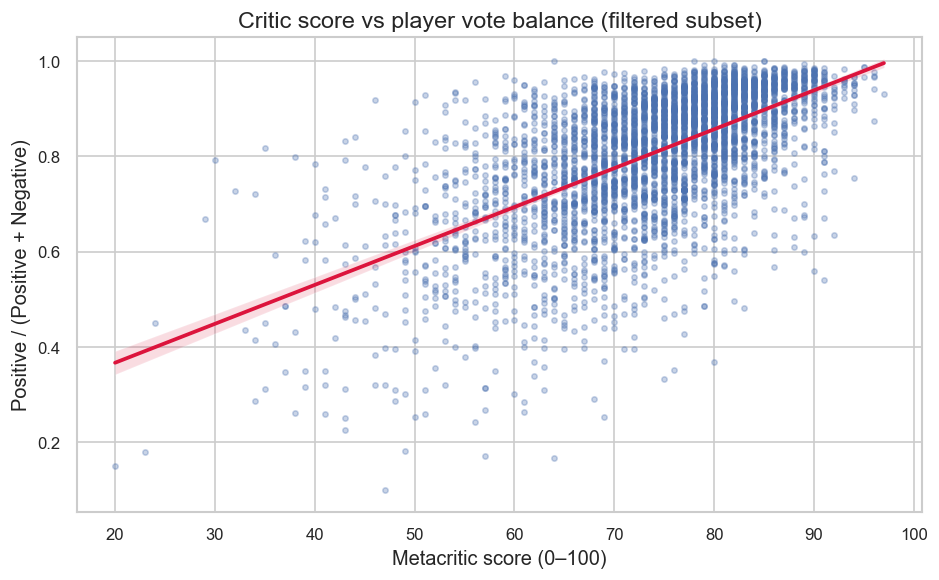

In [18]:
# Section 2.6c — Metacritic vs player vote balance (single figure)
meta_block = mine.loc[
    (mine["Metacritic score"] > 0) & (vote_total >= 10),
    ["Metacritic score", "review_ratio"],
].dropna()
meta_r, meta_p = stats.pearsonr(meta_block["Metacritic score"], meta_block["review_ratio"])
print(f"【test log】 Metacritic vs review_ratio: n={len(meta_block)}, r={meta_r:.4f}, p={meta_p:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=meta_block.sample(min(4000, len(meta_block)), random_state=RANDOM_STATE),
    x="Metacritic score",
    y="review_ratio",
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "crimson"},
    ax=ax,
)
ax.set_xlabel("Metacritic score (0–100)")
ax.set_ylabel("Positive / (Positive + Negative)")
ax.set_title("Critic score vs player vote balance (filtered subset)")
plt.tight_layout()
plt.show()


Among **4,144** eligible rows the regression slope is clearly positive with Pearson **r ≈ 0.60**, so professional and crowd sentiment align on the subset Steam actually scores, even though most catalogue rows lack a Metacritic value.

在 **4,144** 条合格记录中回归斜率明显为正，Pearson **r ≈ 0.60**，说明在 Steam 实际给出媒体分的子集上，专业评分与玩家好评率同向，尽管全库大多数行没有 Metacritic。


Where Metacritic exists, critic and player views move together moderately, yet coverage is thin relative to the full **122,611** rows, so media score cannot stand in for community sentiment catalogue-wide. A genre-level price summary comes next to see whether taxonomy separates markets after these pairwise checks.

在有 Metacritic 的范围内，媒体与玩家评价中度同向，但覆盖率相对 **122,611** 行仍偏薄，媒体分不能代表全库口碑。下一步用类型中位价查看分类是否在上述两两关系之外区分市场。


Finally, median **`Price`** by primary **`Genres`** token (genres with at least **500** listings) tests whether taxonomy separates commercial positioning beyond raw correlations. **`Free To Play`** is reported separately because a zero list price is built into that business model rather than a discoverable price signal.

最后按主 **`Genres`** 标签汇总中位 **`Price`**（至少 **500** 款），查看类型是否在相关结构之外区分商业定位；**`Free To Play`** 单独说明，因其零价来自商业模式而非可比的定价信号。


【test log】 primary genres by median Price (n>=500, all):
               listings  median_price
genre_primary                        
Simulation         2449          4.99
RPG                1910          4.99
Strategy           1585          3.99
Racing              549          3.99
Action            45888          2.99
Indie             10723          2.99
Adventure         24053          2.99
Casual            23826          1.99
Free To Play        870          0.00
【test log】 Free To Play (excluded from bar chart): listings=870, median_price=0.00


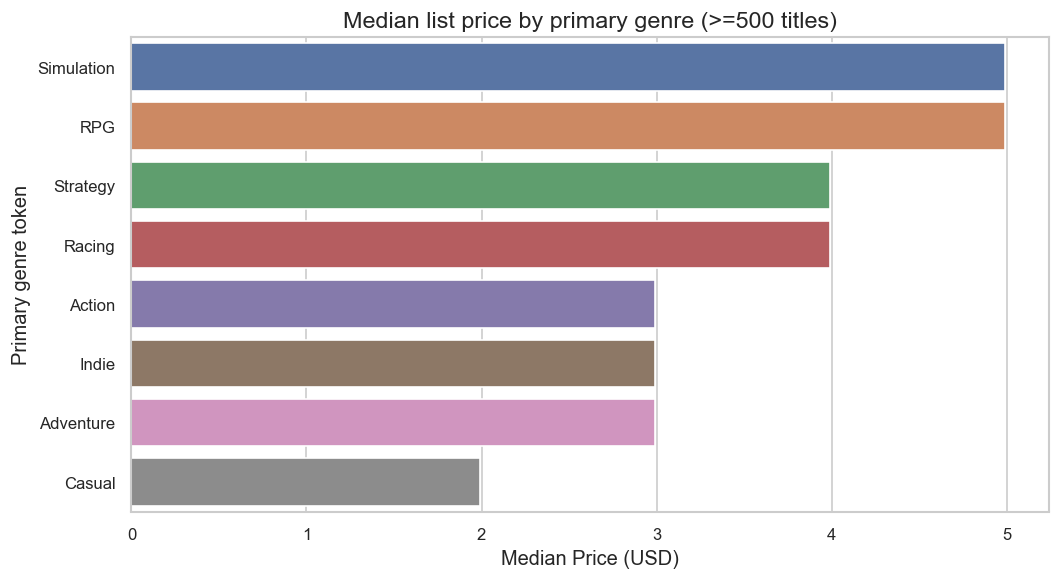

【test log】 Price == 0 rows: 26206
【test log】 Price == 0 with Discount > 0: 39


In [19]:
# Section 2.6d — median price by primary genre (horizontal bar, single figure)

def primary_genre_token(cell):
    """First comma-separated genre token."""
    if pd.isna(cell):
        return np.nan
    return str(cell).split(",")[0].strip()


df_genre = df.copy()
df_genre["genre_primary"] = df_genre["Genres"].map(primary_genre_token)
genre_stats = (
    df_genre.groupby("genre_primary")
    .agg(listings=("genre_primary", "size"), median_price=("Price", "median"))
    .query("listings >= 500")
    .sort_values("median_price", ascending=False)
    .head(12)
)
print("【test log】 primary genres by median Price (n>=500, all):")
print(genre_stats.to_string())
f2p_row = genre_stats.loc["Free To Play"] if "Free To Play" in genre_stats.index else None
if f2p_row is not None:
    print(
        "【test log】 Free To Play (excluded from bar chart):",
        f"listings={int(f2p_row['listings'])}, median_price={f2p_row['median_price']:.2f}",
    )

genre_plot = genre_stats.query("genre_primary != 'Free To Play'")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=genre_plot.reset_index(),
    y="genre_primary",
    x="median_price",
    hue="genre_primary",
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_xlabel("Median Price (USD)")
ax.set_ylabel("Primary genre token")
ax.set_title("Median list price by primary genre (>=500 titles)")
plt.tight_layout()
plt.show()

print("【test log】 Price == 0 rows:", int((df["Price"] == 0).sum()))
print("【test log】 Price == 0 with Discount > 0:", int(((df["Price"] == 0) & (df["Discount"] > 0)).sum()))


Among primary genres with **≥ 500** listings, the plotted bars (excluding **Free To Play**) put **Simulation** and **RPG** at the top with median **$4.99**, then **Strategy** / **Racing** near **$3.99–$4.99**, and mass **Action** / **Adventure** / **Indie** / **Casual** between **$1.99** and **$2.99**—consistent with the **【test log】** table. **Free To Play** (**870** titles) still shows **$0.00** in that table but is omitted from the figure because Steam’s `Price` field is definitionally zero for that model; it does not rank “cheaper” games, only restates the F2P label. Catalogue-wide **26,206** rows have **`Price` = 0**, yet only **39** also show **`Discount` > 0**, so bulk zero prices are mostly genuine free/F2P rows rather than discount-encoding errors.

在至少 **500** 款的主类型中，条形图（已排除 **Free To Play**）最高为 **Simulation** 与 **RPG**（中位 **$4.99**），其次 **Strategy** / **Racing**（约 **$3.99–$4.99**），大众 **Action** / **Adventure** / **Indie** / **Casual** 落在 **$1.99–$2.99**，与 **【test log】** 表一致。**Free To Play**（**870** 款）在表中仍为 **$0.00**，但不入图：Steam 的 `Price` 对该模式按定义为零，不能用来比较“谁更便宜”，只是重复 F2P 标签。全库 **26,206** 行 **`Price` = 0**，仅 **39** 行同时 **`Discount` > 0**，大量零价更像真实免费/F2P 而非折扣字段错误。


Section 2.6 therefore points preprocessing toward dropping empty media fields, parsing owner bands and release dates, keeping one playtime aggregate, and deferring sparse **`User score`** until an imputation rule exists. NHST or supervised work can next test whether genre dummies add signal beyond the engagement block already correlated here.

§2.6 由此将预处理指向：剔除空媒体列、解析拥有者档位与发行日、保留单一游玩时长聚合，并对稀疏 **`User score`** 暂缓建模；后续可用 NHST 或监督学习检验类型哑变量是否在已相关的参与度块之外仍有解释力。


### 2.7 Summary

#### Correlations to question

- **`Recommendations` vs `Positive` (r ≈ 0.90)** — likely the same enthusiasm construct twice; not two independent drivers.
- **`Average` vs `Median` playtime (r ≈ 0.99)** — duplicate feature; keep one only.
- **`Positive` vs `Peak CCU` (r ≈ 0.85)** — direct link, blockbuster tails; use **log1p** in plots.

#### Distribution / outliers

- **`Peak CCU`**: ~**84%** zeros, extreme highs — raw boxplots misleading.
- **Votes & playtime**: heavy zero mass and right skew.
- **`User score`**: only **40** non-zero rows — skip catalogue-wide use.

#### Weaker or subset-only links

- **`Metacritic` vs `review_ratio` (r ≈ 0.60, n ≈ 4,144)** — only where critic scores exist.
- **`Discount` vs `Price` (~0)** — no full-catalogue linear tie.
- **Genre medians** — indirect hint (**Simulation/RPG** ~**$5** vs mass ~**$2–3**), separate from the engagement block.

#### Drop or defer

- **`Movies`**, **`Score rank`**: empty / near-empty.
- **`AppID`** valid key; **`Name`** repeats are display-only (**1,156**).



### 2.7 总结

#### 相关性质疑

- **`Recommendations` 与 `Positive`（r ≈ 0.90）** — 可能重复计量同一“玩家热度”，不宜当作两个独立驱动。
- **两类游玩时长（r ≈ 0.99）** — 重复特征，只保留一列。
- **`Positive` 与 `Peak CCU`（r ≈ 0.85）** — 直接同向，爆款长尾主导；宜看 **log1p**。

#### 分布 / 异常

- **`Peak CCU`**：约 **84%** 为 0、极高离群 — 原始箱线图失真。
- **票数与游玩时长**：零值多、严重右偏。
- **`User score`**：仅 **40** 行非零 — 不宜全库建模。

#### 较弱或仅子集成立

- **`Metacritic` 与 `review_ratio`（r ≈ 0.60，n ≈ 4,144）** — 仅有媒体分的子集上成立。
- **`Discount` 与 `Price`（≈0）** — 全库几乎无线性关系。
- **类型中位价** — 间接分类线索（**Simulation/RPG** 约 **$5** vs 大众约 **$2–3**），不属于参与度相关块。

#### 剔除或暂缓

- **`Movies`**、**`Score rank`**：空/近空列。
- **`AppID`** 可作主键；**`Name`** 重复仅为展示名（**1,156** 条）。



## Part 3: Data preprocessing

Section 2 left audit clues (§2.7). Part 3 applies them on a working copy while **`df_raw`** and **`df`** stay untouched. Because later branches (supervised, unsupervised, or time-series) are not fixed yet, this stage uses a **defensive, lossless** stance: no mean/median fill on continuous telemetry, original columns kept, and missingness surfaced via **`has_*`** indicators where gaps are informative. §3.1 trims unsuitable columns into **`df_prep`**; §3.2 prunes only demonstrably hollow rows, parses owner intervals in parallel, then saves **`df_foundation`** as the shared starting point for all downstream paths.



第二节留下审计线索（§2.7）。第三节在工作副本上落实，**`df_raw`** 与 **`df`** 不变。后续监督/无监督/时间序列路径尚未定稿，本阶段采取**防御性、无损**策略：不对 `Price`、游玩时长等连续变量做均值/中位数填补；高缺失列保留原值并增 **`has_*`** 指示；`Estimated owners` 解析为平行数值列且保留原区间列。§3.1 得 **`df_prep`**；§3.2 仅删可证实的空壳行并落盘 **`df_foundation`**，供各研究分支共用。


### 3.1 Drop unsuitable columns

**Order:** remove low-value or redundant columns first so later row-level work and regex parsing run on a slimmer table (**28** columns instead of **40**). The table lists **12 columns** to drop, with missing counts on the full extract and the §2.5–§2.7 rationale. Row pruning and missing indicators are deferred to §3.2.

| Column | Missing (n) | Missing (%) | Reason to drop |
| :--- | ---: | ---: | :--- |
| `Movies` | 122,611 | 100.00 | Entirely empty (§2.5) |
| `Score rank` | 122,571 | 99.97 | Near-empty (§2.5) |
| `Metacritic url` | 118,355 | 96.53 | Link only |
| `Reviews` | 110,541 | 90.16 | Long text — NLP only |
| `Notes` | 100,153 | 81.68 | Sparse notes |
| `Website` | 72,935 | 59.48 | Storefront URL |
| `Support url` | 68,469 | 55.84 | Storefront URL |
| `Support email` | 22,263 | 18.16 | Contact link |
| `Header image` | 81 | 0.07 | Image URL |
| `Screenshots` | 6,018 | 4.91 | Screenshot URLs |
| `Median playtime forever` | 0 | 0.00 | Duplicate of average playtime (§2.7) |
| `Median playtime two weeks` | 0 | 0.00 | Duplicate playtime window (§2.7) |

Columns such as `Positive`, `Price`, `Genres`, and `Estimated owners` are **kept** for later steps.


### 3.1 剔除不适用的列

**顺序：** 先删列、后删行，减轻后续正则与行级判断的负担。下表为计划删除的 **12** 列、缺失情况与 §2.5–§2.7 理由（全库 **122,611** 行）。行级空壳剔除与 `has_*` 列放在 §3.2。

| 列名 | 缺失 (n) | 缺失 (%) | 剔除理由 |
| :--- | ---: | ---: | :--- |
| `Movies` | 122,611 | 100.00 | 全空（§2.5） |
| `Score rank` | 122,571 | 99.97 | 近全空（§2.5） |
| `Metacritic url` | 118,355 | 96.53 | 仅链接 |
| `Reviews` | 110,541 | 90.16 | 长文本，仅 NLP |
| `Notes` | 100,153 | 81.68 | 稀疏备注 |
| `Website` | 72,935 | 59.48 | 商店 URL |
| `Support url` | 68,469 | 55.84 | 商店 URL |
| `Support email` | 22,263 | 18.16 | 联系邮箱 |
| `Header image` | 81 | 0.07 | 图片 URL |
| `Screenshots` | 6,018 | 4.91 | 截图 URL |
| `Median playtime forever` | 0 | 0.00 | 与均值游玩时长重复（§2.7） |
| `Median playtime two weeks` | 0 | 0.00 | 重复游玩窗口（§2.7） |

`Positive`、`Price`、`Genres`、`Estimated owners` 等**保留**。

In [20]:
# Section 3.1 — drop unsuitable columns; create df_prep
DROP_UNSUITABLE = [
    "Movies",
    "Score rank",
    "Metacritic url",
    "Reviews",
    "Notes",
    "Website",
    "Support url",
    "Support email",
    "Header image",
    "Screenshots",
    "Median playtime forever",
    "Median playtime two weeks",
]

shape_before = df.shape
df_prep = df.drop(columns=DROP_UNSUITABLE)
shape_after = df_prep.shape

print("【test log】 shape before drop:", shape_before)
print("【test log】 columns removed (n=12):", DROP_UNSUITABLE)
print("【test log】 shape after drop:", shape_after)
print("【test log】 rows unchanged:", shape_after[0] == shape_before[0])
print("【test log】 columns removed count:", shape_before[1] - shape_after[1])

【test log】 shape before drop: (122611, 40)
【test log】 columns removed (n=12): ['Movies', 'Score rank', 'Metacritic url', 'Reviews', 'Notes', 'Website', 'Support url', 'Support email', 'Header image', 'Screenshots', 'Median playtime forever', 'Median playtime two weeks']
【test log】 shape after drop: (122611, 28)
【test log】 rows unchanged: True
【test log】 columns removed count: 12


After the drop, **`df_prep.shape`** is **(122,611, 28)** — all catalogue rows remain, **12** columns from the table are removed, and **28** columns are retained for the next preprocessing steps.

剔除后 **`df_prep.shape`** 为 **(122,611, 28)**：行数不变，删除上表 **12** 列，保留 **28** 列供后续处理。

### 3.2 Handle missing value

After §3.1, **`df_prep`** has **122,611** rows × **28** columns. Gaps cluster in taxonomy and long text; **`Price`**, votes, **`Peak CCU`**, and playtime columns have **zero** NA in the core numeric block. **`Metacritic score`** / **`User score`** are mostly **0**, not NA — a coverage issue, not a hole to median-fill.

**Processing order (lighten before heavy work):** (1) drop only bad rows → (2) parse **`Estimated owners`** → (3) add **`has_*`** flags → (4) checkpoint **`df_foundation`**. No mean/median fill on continuous telemetry.

#### Remaining NA on `df_prep`

| Column | Missing (n) | Missing (%) |
| :--- | ---: | ---: |
| `Tags` | 39,265 | 32.02 |
| `Categories` | 8,953 | 7.30 |
| `Publishers` | 8,909 | 7.27 |
| `About the game` | 8,449 | 6.89 |
| `Developers` | 8,437 | 6.88 |
| `Genres` | 8,413 | 6.86 |
| `Name` | 1 | 0.00 |

Roughly **40,699** rows miss at least one taxonomy/description field, but most still carry prices and votes. Only **7,982** rows lack **all five** of `Genres` / `Categories` / `Developers` / `Publishers` / `Tags`; on those rows, votes, **`Peak CCU`**, list **`Price`**, and average playtime are all **0** — catalogue shells with no engagement signal, not merely “untagged” listings.

#### Row deletion — narrow rule

| Rule | Rows hit | Rationale |
| :--- | ---: | :--- |
| `Name` is NA | **1** (inside shell set) | Broken label / integrity |
| All five taxonomy cols NA **and** no engagement (`Positive`+`Negative` = 0, `Peak CCU` = 0, `Average playtime forever` = 0) | **7,982** | No taxonomy and no telemetry left worth keeping |
| `dropna(how="any")` on taxonomy | **~40,699** | **Rejected** — would discard thinly tagged but real listings |

#### Univariate fill — what fits this table

| Target | Mean / median | Mode / constant | Decision |
| :--- | :--- | :--- | :--- |
| `Price`, playtime, votes, `Peak CCU`, `Discount` | Not applicable (0 NA); would distort skew | — | **Forbidden** |
| `Tags`, `Genres`, … | Undefined on text | Forces “Action”-like labels onto **32%** of rows | **Reject**; keep NA |
| `Metacritic` / `User score` | Blurs “no score” with “low score” | — | Keep **0** semantics; subset later |
| `About the game` | — | `"Unknown"` alters NLP cohorts | Keep NA; tabular paths use **`has_about_the_game`** |

#### Similar-row imputation (KNN / hot-deck)

Theoretically useful when one taxonomy field is present and another is missing (e.g. `Categories` present, `Genres` NA). Deferred here: **122k**-row cost, encoding blow-up, and branch-specific leakage risk. A future supervised branch can revisit on a **encoded** sub-matrix; foundation stage stays non-destructive.

#### Implemented defensive actions (code below)

- **`has_*`** for every column with NA rate ≥ **5%** on `df_prep` (`Tags` through `Genres`, plus `About the game`); **1** = observed, **0** = NA; original column unchanged.
- Regex on **`Estimated owners`** → **`owner_lowerbound`**, **`owner_midpoint`**; interval string retained.
- **`df_foundation`** = checkpoint after the above; no continuous imputation.


### 3.2 缺失处理

§3.1 后 **`df_prep`** 为 **122,611** 行 × **28** 列。缺口集中在分类/标签与长文本；`Price`、投票、`Peak CCU`、游玩时长等核心数值列在 NA 意义上**为零**。**`Metacritic score`** / **`User score`** 多为 **0** 而非 NA，属于覆盖稀疏，不宜用中位数填补。

**处理顺序（先减负）：** (1) 仅删坏行 → (2) 解析 **`Estimated owners`** → (3) 增 **`has_*`** → (4) 保存 **`df_foundation`**。禁止对连续遥测做均值/中位数填补。

#### `df_prep` 上仍存在的 NA

| 列名 | 缺失 (n) | 缺失 (%) |
| :--- | ---: | ---: |
| `Tags` | 39,265 | 32.02 |
| `Categories` | 8,953 | 7.30 |
| `Publishers` | 8,909 | 7.27 |
| `About the game` | 8,449 | 6.89 |
| `Developers` | 8,437 | 6.88 |
| `Genres` | 8,413 | 6.86 |
| `Name` | 1 | 0.00 |

约 **40,699** 行在分类/描述字段中至少缺一项，但多数仍有价格与投票。仅 **7,982** 行在五类标签列**全部** NA；这些行上投票、`Peak CCU`、标价、平均游玩时长均为 **0**——无分类也无参与度的空壳条目，而非“仅缺标签”的正常未标注游戏。

#### 删行 — 窄规则

| 规则 | 命中行数 | 理由 |
| :--- | ---: | :--- |
| `Name` 为 NA | **1**（含于空壳集） | 标签完整性故障 |
| 五类标签全 NA **且** 无参与度（投票和为 0、`Peak CCU`=0、`Average playtime forever`=0） | **7,982** | 无分类且无遥测，保留意义低 |
| 分类列任一 NA 即删行 | **~40,699** | **否决** — 会丢掉大量仅有薄标签但有价格的条目 |

#### 单变量填充 — 与本表的关系

| 对象 | 均值/中位数 | 众数/常数 | 决策 |
| :--- | :--- | :--- | :--- |
| `Price`、游玩时长、投票等 | 无 NA；会破坏右偏分布 | — | **禁止** |
| `Tags`、`Genres` 等 | 文本无定义 | 众数会把高频类型强加给 **32%** 行 | **拒绝**；保留 NA |
| `Metacritic` / `User score` | “无分”与“低分”混淆 | — | 保留 **0** 语义 |
| `About the game` | — | `"Unknown"` 改变 NLP 队列 | 保留 NA；表格路径用 **`has_about_the_game`** |

#### 相似行插补（KNN 等）

在“有 `Categories`、缺 `Genres`”等情形下理论上可用，但全库 **12 万行**成本高、编码维数大且易泄漏；基础阶段保持非破坏性，留待某一分支在编码子矩阵上再议。

#### 本节代码落实

- 对 `df_prep` 上 NA 率 ≥ **5%** 的列增 **`has_*`**（**1**=有值，**0**=NA），原列不动。
- 正则解析 **`Estimated owners`** → **`owner_lowerbound`**、**`owner_midpoint`**，原区间列保留。
- 结束后 **`df_foundation`** 检查点；不做连续变量插补。


In [21]:
# Section 3.2 — defensive missing handling; create df_foundation
import re
import numpy as np

work = df_prep.copy()
rows_before = len(work)

# Step 1: drop hollow catalogue rows (narrow rule; reduces row count before parsing)
TAXONOMY_COLS = ["Genres", "Categories", "Developers", "Publishers", "Tags"]
all_taxonomy_na = work[TAXONOMY_COLS].isna().all(axis=1)
has_engagement = (
    (work["Positive"] + work["Negative"] > 0)
    | (work["Peak CCU"] > 0)
    | (work["Average playtime forever"] > 0)
)
bad_row = work["Name"].isna() | (all_taxonomy_na & ~has_engagement)

print("【test log】 rows before row prune:", rows_before)
print("【test log】 bad rows (Name NA or hollow taxonomy + no engagement):", int(bad_row.sum()))
print("【test log】 bad rows with all taxonomy NA:", int((bad_row & all_taxonomy_na).sum()))
print("【test log】 bad rows with Name NA:", int(work.loc[bad_row, "Name"].isna().sum()))

work = work.loc[~bad_row].copy()
rows_after = len(work)

# Step 2: parse Estimated owners (keep original interval column)
OWNER_PATTERN = re.compile(r"([\d,]+)\s*-\s*([\d,]+)")


def parse_owner_bounds(text):
    if pd.isna(text):
        return np.nan, np.nan
    match = OWNER_PATTERN.search(str(text))
    if not match:
        return np.nan, np.nan
    lower = int(match.group(1).replace(",", ""))
    upper = int(match.group(2).replace(",", ""))
    return lower, (lower + upper) / 2.0


parsed = work["Estimated owners"].map(parse_owner_bounds)
work["owner_lowerbound"] = parsed.map(lambda x: x[0])
work["owner_midpoint"] = parsed.map(lambda x: x[1])

owner_nonempty = work["Estimated owners"].notna()
parse_fail = owner_nonempty & work["owner_lowerbound"].isna()
print("【test log】 Estimated owners non-null:", int(owner_nonempty.sum()))
print("【test log】 owner regex parse failures:", int(parse_fail.sum()))

# Step 3: missing indicators for columns with NA rate >= 5% on df_prep (no fill on originals)
HIGH_NA_COLS = [
    "Tags",
    "Categories",
    "Publishers",
    "About the game",
    "Developers",
    "Genres",
]
HAS_COLS = []
for col in HIGH_NA_COLS:
    flag = "has_" + col.lower().replace(" ", "_")
    work[flag] = work[col].notna().astype(int)
    HAS_COLS.append(flag)

print("【test log】 has_* columns added:", HAS_COLS)

# Guard: continuous telemetry must stay unfilled
FORBID_FILL = [
    "Price",
    "Positive",
    "Negative",
    "Peak CCU",
    "Average playtime forever",
    "Average playtime two weeks",
    "Recommendations",
    "Discount",
]
na_on_continuous = work[FORBID_FILL].isna().sum()
print("【test log】 NA on continuous columns (expect all 0):", na_on_continuous.to_dict())

df_foundation = dataframe_checkpoint(work)
print("【test log】 rows after prune:", rows_after)
print("【test log】 df_foundation.shape:", df_foundation.shape)
print("【test log】 new columns vs df_prep:", df_foundation.shape[1] - df_prep.shape[1])


【test log】 rows before row prune: 122611
【test log】 bad rows (Name NA or hollow taxonomy + no engagement): 7982
【test log】 bad rows with all taxonomy NA: 7982
【test log】 bad rows with Name NA: 1
【test log】 Estimated owners non-null: 114629
【test log】 owner regex parse failures: 0
【test log】 has_* columns added: ['has_tags', 'has_categories', 'has_publishers', 'has_about_the_game', 'has_developers', 'has_genres']
【test log】 NA on continuous columns (expect all 0): {'Price': 0, 'Positive': 0, 'Negative': 0, 'Peak CCU': 0, 'Average playtime forever': 0, 'Average playtime two weeks': 0, 'Recommendations': 0, 'Discount': 0}
【test log】 rows after prune: 114629
【test log】 df_foundation.shape: (114629, 36)
【test log】 new columns vs df_prep: 8


Row pruning removes **7,982** hollow listings (**6.51%** of `df_prep`), leaving **114,629** rows. **`df_foundation`** adds **8** columns: **`owner_lowerbound`**, **`owner_midpoint`**, and six **`has_*`** indicators; shape is **(114,629, 36)**. Original taxonomy text and interval **`Estimated owners`** remain; continuous telemetry is untouched. This checkpoint is the shared entry for later supervised, unsupervised, or time-series branches.


删行去掉 **7,982** 条空壳记录（占 `df_prep` 的 **6.51%**），余 **114,629** 行。**`df_foundation`** 新增 **8** 列：`owner_lowerbound`、`owner_midpoint` 与六个 **`has_*`** 指示，规模为 **(114,629, 36)**。分类原文与区间型 **`Estimated owners`** 均保留，连续遥测未做插补。该检查点作为后续各研究分支的通用起点。


### 3.3 Outlier handling

§2.3–§2.3.1 and §2.7 already flagged **which numeric fields behave abnormally** on the raw extract. Before treatment on **`df_foundation`**, this step re-lists those columns and separates **structural zero inflation** from **extreme right-tail highs**.

#### Columns flagged in Section 2

| Column | §2 evidence | Nature |
| :--- | :--- | :--- |
| `Average playtime forever` | Skew ≈ **263** (§2.3.1); median **0**; max **millions** of minutes; ~**79%** zeros | Zero-inflated + extreme tail |
| `Peak CCU` | Skew ≈ **210**; ~**84%** zeros; max **1,013,936**; raw boxplot at 0 | Zero-inflated + viral spikes |
| `Positive` | Skew ≈ **178**; ~**34%** zeros; max **7,642,084**; **10** rows > **1M** (§2.3) | Zero-inflated + mega-hits |
| `Recommendations` | High skew; long whisker; **r ≈ 0.90** with `Positive` (§2.7) | Engagement block — duplicate signal |
| `Negative` | Seven-digit max; right-skewed (§2.3) | Secondary vote tail |
| `Price` | Skew ≈ **22**; ~**21%** zeros; visible IQR on raw scale (§2.3.1) | Commerce skew + valid **$0**/F2P |
| `Average playtime two weeks` | Very high skew; ~**97%** zeros | Sparse recent-play field |
| `DLC count` / `Achievements` | \|skew\| > 1 in §2.3 sweep | Milder tails — lower priority |
| `Metacritic score` | Mostly **0** — sparse coverage | Subset analysis, not clipping |
| `User score` | **40** non-zero rows (§2.7) | Degenerate — skip outlier rules |
| `Discount` | Flat vs `Price`; **39** rows `Price = 0` & `Discount > 0` (§2.6) | Logic fault, not a high tail |

Most flags are **inactive zeros plus legitimate blockbusters**, not a small bad-data cluster. Deleting Tukey/z points on votes or CCU would drop real hits. §3.2’s defensive stance continues: **keep raw telemetry**, then use **flags or log transforms** per branch.

The code below re-quantifies skew, zero share, and Tukey counts on **`df_foundation`** (**114,629** rows).

### 3.3 异常值处理

§2.3–§2.3.1 与 §2.7 已在原始表上标出**异常数值列**。在对 **`df_foundation`** 处理前，本节先复述这些列，并区分**结构性零堆积**与**极端右尾高值**。

#### 第二节已标出的列

| 列名 | §2 依据 | 性质 |
| :--- | :--- | :--- |
| `Average playtime forever` | 偏度约 **263**；中位数 **0**；最大**数百万**分钟；约 **79%** 为零 | 零膨胀 + 极端尾 |
| `Peak CCU` | 偏度约 **210**；约 **84%** 为零；最大 **1,013,936** | 零膨胀 + 爆款尖峰 |
| `Positive` | 偏度约 **178**；约 **34%** 为零；最大 **7,642,084**；**10** 行超 **100 万**好评 | 零膨胀 + 超大体量 |
| `Recommendations` | 高偏度；与 `Positive` **r≈0.90**（§2.7） | 参与度块 — 信息重复 |
| `Negative` | 七位数最大值、右偏 | 差评尾 |
| `Price` | 偏度约 **22**；约 **21%** 零价；原始尺度箱体可见 | 商业右偏 + 合理零价 |
| `Average playtime two weeks` | 极高偏度；约 **97%** 为零 | 近两周信号稀疏 |
| `DLC count` / `Achievements` | §2.3 中 \|偏度\|>1 | 尾部较弱 — 优先级低 |
| `Metacritic score` | 多为 **0** | 宜子集分析 |
| `User score` | 仅 **40** 行非零（§2.7） | 退化列 — 跳过 |
| `Discount` | 与 `Price` 近乎无关；**39** 行零价却有折扣（§2.6） | 逻辑矛盾 |

多数是**不活跃零值 + 真实长尾爆款**，不宜按 Tukey/z-score 删行。延续 §3.2：**保留原值**，再按分支做**标记或 log 变换**。

下列代码在 **`df_foundation`**（**114,629** 行）上复算偏度、零占比与 Tukey 计数。

In [22]:
# Section 3.3 — outlier recap audit on df_foundation
from scipy import stats

OUTLIER_AUDIT_COLS = [
    "Average playtime forever",
    "Average playtime two weeks",
    "Peak CCU",
    "Positive",
    "Negative",
    "Recommendations",
    "Price",
    "Discount",
    "Metacritic score",
    "User score",
    "Achievements",
    "DLC count",
    "owner_lowerbound",
    "owner_midpoint",
]

audit_rows = []
for col in OUTLIER_AUDIT_COLS:
    ser = df_foundation[col]
    q1, q3 = ser.quantile(0.25), ser.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    z = np.abs(stats.zscore(ser.astype(float)))
    audit_rows.append(
        {
            "column": col,
            "zero_pct": round(float((ser == 0).mean() * 100), 2),
            "median": float(ser.median()),
            "p99": float(ser.quantile(0.99)),
            "max": float(ser.max()),
            "skew": round(float(stats.skew(ser.astype(float))), 2),
            "tukey_high": int((ser > upper).sum()),
            "tukey_low": int((ser < lower).sum()),
            "z_gt_3": int((z > 3).sum()),
        }
    )

audit_df = pd.DataFrame(audit_rows).sort_values("skew", ascending=False)
print("【test log】 df_foundation rows:", df_foundation.shape[0])
print("【test log】 outlier audit (sorted by skew):")
print(audit_df.to_string(index=False))

pos_mega = int((df_foundation["Positive"] > 1_000_000).sum())
price_disc = int(
    ((df_foundation["Price"] == 0) & (df_foundation["Discount"] > 0)).sum()
)
print("【test log】 Positive > 1,000,000:", pos_mega)
print("【test log】 Price == 0 and Discount > 0:", price_disc)

【test log】 df_foundation rows: 114629
【test log】 outlier audit (sorted by skew):
                    column  zero_pct   median        p99          max   skew  tukey_high  tukey_low  z_gt_3
  Average playtime forever     77.21     0.00    2418.16   3429544.00 254.20       26119          0      57
                  Peak CCU     82.84     0.00     258.00   1013936.00 203.00       19676          0      87
                  Positive     29.91     6.00   14419.92   7642084.00 171.97       19470          0     236
                 DLC count     84.50     0.00       7.00      3703.00 166.16       17771          0     134
                  Negative     41.19     1.00    2353.72   1173003.00 151.68       18996          0     165
           Recommendations     81.76     0.00   13618.04   4830455.00 110.15       20904          0     286
          owner_lowerbound     77.70     0.00 1000000.00 100000000.00  73.41       25566          0     220
            owner_midpoint     11.92 10000.00 1500000.0

On **`df_foundation`**, **`Average playtime forever`** still tops skew (**254.2**) with **77.2%** zeros and max **3,429,544** minutes; **`Peak CCU`** follows (**203.0** skew, **82.8%** zeros, max **1,013,936**). **`Positive`** has **29.9%** zeros, max **7,642,084**, and **10** rows above **1M** positives. Tukey-high counts are large (**~19k–39k** rows) because zero inflation collapses the IQR — they mark **tail mass**, not a small bad cluster. **`Discount`** has **0** Tukey-high hits here; **39** rows with `Price = 0` and `Discount > 0` are **logic** outliers to flag separately. The next step applies **`log1p`** parallel columns to the six core skewed telemetry fields while keeping raw values.

在 **`df_foundation`** 上，**`Average playtime forever`** 偏度仍最高（**254.2**），**77.2%** 为零、最大 **3,429,544** 分钟；**`Peak CCU`** 次之（**203.0**，**82.8%** 为零，最大 **1,013,936**）。**`Positive`** 零占比 **29.9%**、最大 **7,642,084**，**10** 行超 **100 万**好评。Tukey 上侧约 **1.9 万–3.9 万** 行，是零膨胀下**尾部体量**而非少量坏点。**`Discount`** Tukey 上侧为 **0**；**39** 行零价却有折扣宜作**逻辑异常**标记。下一步对六项核心偏态遥测增 **`log1p`** 平行列，原列保留。

#### Log1p smoothing for core skewed telemetry

The audit table shows **destructive right skew** on the main commerce/engagement block (playtime, CCU, votes, recommendations, price). **`Discount`** is excluded here (near-symmetric at this scale; logic faults handled separately). **`owner_lowerbound`** / **`owner_midpoint`** are ordinal-tier parses, not count telemetry — left on raw tiers for now.

**Action:** add parallel **`log_<column>`** fields via **`np.log1p`** on:

`Average playtime forever`, `Peak CCU`, `Positive`, `Negative`, `Recommendations`, `Price`

Raw columns stay unchanged for audit and branch-specific models; correlation and regression paths can use the log layer (as in §2.6’s log-scatter). Checkpoint **`df_foundation`** again after the six columns are appended.

#### 对核心偏态遥测做 log1p 平滑

审计表显示主要商业/参与度指标（游玩时长、CCU、投票、推荐、价格）呈**毁灭级右偏**。**`Discount`** 本节不处理（分布近对称；逻辑矛盾另议）。**`owner_*`** 为档位解析值，暂不做 log。

**操作：** 对下列六列用 **`np.log1p`** 生成平行列 **`log_<列名>`**，原列不动：

`Average playtime forever`、`Peak CCU`、`Positive`、`Negative`、`Recommendations`、`Price`

保留原值供审计与分支建模；相关/回归路径可使用 log 层（与 §2.6 log 散点一致）。追加六列后再次保存 **`df_foundation`** 检查点。

In [23]:
# Section 3.3b — log1p parallel columns for extreme-skew telemetry
from scipy import stats

SKEWED_COLS = [
    "Average playtime forever",
    "Peak CCU",
    "Positive",
    "Negative",
    "Recommendations",
    "Price",
]

work = df_foundation.copy()
cols_before = work.shape[1]

skew_compare = []
for col in SKEWED_COLS:
    log_col = f"log_{col}"
    work[log_col] = np.log1p(work[col])
    raw_skew = float(stats.skew(work[col].astype(float)))
    log_skew = float(stats.skew(work[log_col].astype(float)))
    skew_compare.append(
        {"column": col, "log_column": log_col, "skew_raw": round(raw_skew, 2), "skew_log1p": round(log_skew, 2)}
    )

skew_compare_df = pd.DataFrame(skew_compare)
print("【test log】 skew before vs after log1p:")
print(skew_compare_df.to_string(index=False))

log_cols_added = [f"log_{c}" for c in SKEWED_COLS]
print("【test log】 log columns added:", log_cols_added)
print("【test log】 columns before:", cols_before, "after:", work.shape[1])

df_foundation = dataframe_checkpoint(work)
print("【test log】 df_foundation.shape:", df_foundation.shape)

【test log】 skew before vs after log1p:
                  column                   log_column  skew_raw  skew_log1p
Average playtime forever log_Average playtime forever    254.20        1.63
                Peak CCU                 log_Peak CCU    203.00        4.27
                Positive                 log_Positive    171.97        1.02
                Negative                 log_Negative    151.68        1.38
         Recommendations          log_Recommendations    110.15        1.95
                   Price                    log_Price     21.92        0.43
【test log】 log columns added: ['log_Average playtime forever', 'log_Peak CCU', 'log_Positive', 'log_Negative', 'log_Recommendations', 'log_Price']
【test log】 columns before: 36 after: 42
【test log】 df_foundation.shape: (114629, 42)


Six **`log1p`** columns are appended; **`df_foundation`** is now **(114,629, 42)**. Skew drops sharply on every targeted field: **`Average playtime forever`** from **254.2** to **1.63**, **`Peak CCU`** from **203.0** to **4.27**, **`Positive`** from **172.0** to **1.02**, **`Negative`** from **151.7** to **1.38**, **`Recommendations`** from **110.2** to **1.95**, **`Price`** from **21.9** to **0.43**. Zeros map to **0** under `log1p`, so inactive listings stay identifiable on both scales. **`Peak CCU`** and playtime logs remain moderately skewed — acceptable for exploratory plots; raw columns remain for exact counts. **`Discount`** and owner tiers are unchanged on this pass.

已追加六个 **`log1p`** 列；**`df_foundation`** 规模为 **(114,629, 42)**。各列偏度显著下降：**`Average playtime forever`** **254.2→1.63**，**`Peak CCU`** **203.0→4.27**，**`Positive`** **172.0→1.02**，**`Negative`** **151.7→1.38**，**`Recommendations`** **110.2→1.95**，**`Price`** **21.9→0.43**。`log1p(0)=0`，不活跃条目在两种尺度上仍可识别。**`Peak CCU`** 与游玩时长 log 列仍有一定偏度，可供探索作图；精确计数仍用原列。**`Discount`** 与 owner 档位本轮未改。

#### Removing values that violate domain logic

Mega-hits (**million** positives, **million** CCU) stay — they are skewed but plausible. This step targets **impossible or inconsistent** measurements:

| Rule | Action | Rationale |
| :--- | :--- | :--- |
| `Average playtime forever` > **60,000** min (~**1,000** h lifetime average) | **Drop row** | Far beyond plausible per-player averages (e.g. **3.4M** min rows) |
| `Average playtime two weeks` > **10,000** min (~**7** h/day for **14** days) | **Drop row** | Biologically implausible cohort average |
| `Price` > **$500** | **Drop row** | No standard single-title list price band; **3** rows |
| `Price` = **0** and `Discount` > **0** | Set `Discount` → **0** | §2.6 logic fault (**39** rows) — F2P cannot be “on sale” |
| `Required age` ∉ **{0, 3, 7, 12, 16, 17, 18}** | Set → **0** (unknown) | Invalid ESRB-style codes (**214** rows) |

Raw and **`log_*`** columns on survivors are kept; **`log_*`** is recomputed only if a logged source column is edited (not needed for age/discount fixes).

#### 按常识剔除/修正不合理取值

百万级好评、百万 **CCU** 等**保留**（偏态但可信）。本节只处理**不可能或不自洽**的测量：

| 规则 | 操作 | 理由 |
| :--- | :--- | :--- |
| `Average playtime forever` > **60,000** 分钟（约 **1000** 小时均值的终身平均） | **删行** | 远超合理人均（如 **343 万** 分钟） |
| `Average playtime two weeks` > **10,000** 分钟（14 天日均约 **7** 小时） | **删行** | 群体均值不合理 |
| `Price` > **$500** | **删行** | 单款标价异常（**3** 行） |
| `Price`=**0** 且 `Discount`>**0** | `Discount` 置 **0** | §2.6 逻辑矛盾（**39** 行）— F2P 不应有折扣 |
| `Required age` ∉ **{0,3,7,12,16,17,18}** | 置 **0**（未知） | 非 ESRB 合法档位（**214** 行） |

存活行的原值与 **`log_*`** 列保留；仅当某 `log_*` 的源列被改动时才需重算（年龄/折扣修正不涉及 log 源列重算）。

In [24]:
# Section 3.3e — remove or fix domain-inconsistent values on df_foundation
VALID_REQUIRED_AGE = {0, 3, 7, 12, 16, 17, 18}
PLAYTIME_FOREVER_MAX_MIN = 60_000  # ~1,000 hours average lifetime playtime
PLAYTIME_TWO_WEEKS_MAX_MIN = 10_000  # ~7 hours per day for 14 days, cohort average
PRICE_LIST_MAX_USD = 500.0

work = df_foundation.copy()
rows_in = len(work)

drop_playtime_forever = work["Average playtime forever"] > PLAYTIME_FOREVER_MAX_MIN
drop_playtime_two_weeks = work["Average playtime two weeks"] > PLAYTIME_TWO_WEEKS_MAX_MIN
drop_price_high = work["Price"] > PRICE_LIST_MAX_USD
drop_row = drop_playtime_forever | drop_playtime_two_weeks | drop_price_high

n_fix_discount_before = int(((work["Price"] == 0) & (work["Discount"] > 0)).sum())
n_fix_age_before = int((~work["Required age"].isin(VALID_REQUIRED_AGE)).sum())

print("【test log】 rows before sanity pass:", rows_in)
print("【test log】 drop — playtime forever >", PLAYTIME_FOREVER_MAX_MIN, ":", int(drop_playtime_forever.sum()))
print(
    "【test log】 drop — playtime two weeks >",
    PLAYTIME_TWO_WEEKS_MAX_MIN,
    ":",
    int(drop_playtime_two_weeks.sum()),
)
print("【test log】 drop — Price >", PRICE_LIST_MAX_USD, ":", int(drop_price_high.sum()))
print("【test log】 drop — any of above:", int(drop_row.sum()))

work = work.loc[~drop_row].copy()

fix_discount = (work["Price"] == 0) & (work["Discount"] > 0)
fix_age = ~work["Required age"].isin(VALID_REQUIRED_AGE)
work.loc[fix_discount, "Discount"] = 0
work.loc[fix_age, "Required age"] = 0

print("【test log】 fix — zero price but Discount > 0 (set to 0):", int(fix_discount.sum()))
print("【test log】 fix — invalid Required age (set to 0):", int(fix_age.sum()))
print(
    "【test log】 (before drop) discount/age fix candidates:",
    n_fix_discount_before,
    "/",
    n_fix_age_before,
)
print("【test log】 rows after sanity pass:", len(work))

df_foundation = dataframe_checkpoint(work)
print("【test log】 df_foundation.shape:", df_foundation.shape)

【test log】 rows before sanity pass: 114629
【test log】 drop — playtime forever > 60000 : 32
【test log】 drop — playtime two weeks > 10000 : 24
【test log】 drop — Price > 500.0 : 3
【test log】 drop — any of above: 53
【test log】 fix — zero price but Discount > 0 (set to 0): 39
【test log】 fix — invalid Required age (set to 0): 214
【test log】 (before drop) discount/age fix candidates: 39 / 214
【test log】 rows after sanity pass: 114576
【test log】 df_foundation.shape: (114576, 42)


The sanity pass removes **53** listings (**0.05%** of **`df_foundation`**) with impossible playtime or list price, leaving **114,576** rows. **39** zero-price rows had **`Discount`** reset to **0**; **214** rows with non-ESRB **`Required age`** codes were set to **0** (unknown). Vote and CCU mega-tails were not clipped. Shape stays **(114,576, 42)**.

常识清洗共删除 **53** 条（占 **`df_foundation` 的 0.05%**），余 **114,576** 行：不可能游玩时长或标价过高。**39** 行零价 **`Discount`** 置 **0**；**214** 行非法 **`Required age`** 置 **0**（未知）。投票/CCU 头部未裁剪。规模 **(114,576, 42)**。

### 3.4 Post-processing check and refinement

After §3.3e, **`df_foundation`** is rechecked before any modelling branch. First, list **missing counts per column**. Then:

- **Text / string fields** (`Genres`, `Developers`, `Tags`, …): fill NA with **`"Unknown"`** so tabular paths never see silent holes. Original **`has_*`** flags from §3.2 stay as-is (they still record whether the value was observed before imputation).
- **Numeric fields**: **no mean/median fill** (extreme skew from §3.3). If only a **tiny** number of NA cells remain, set them to **0**; if a numeric column still has large NA mass, leave it for subset rules rather than inventing a central tendency.

The code prints before/after missing tables and updates **`df_foundation`**.


### 3.4 数据处理结果检查与完善

§3.3e 之后，在进入建模分支前对 **`df_foundation`** 再检查。先输出**各列缺失行数**，再：

- **文本/字符串列**（`Genres`、`Developers`、`Tags` 等）：NA 填 **`"Unknown"`**，避免表格路径出现静默空洞；§3.2 的 **`has_*`** 保留（仍表示填补前是否曾有值）。
- **数值列**：**禁止**均值/中位数填补（§3.3 已确认极端偏态）。仅当 NA **极少**时用 **0**；若某数值列仍大面积 NA，不做中心趋势插补，留待子集规则。

代码打印处理前后缺失表，并写回 **`df_foundation`**。


In [25]:
# Section 3.4 — missing-value audit and targeted fill on df_foundation
TEXT_FILL_UNKNOWN = [
    "Tags",
    "Categories",
    "Publishers",
    "About the game",
    "Developers",
    "Genres",
]
# Tiny numeric gaps only: fill 0 (never mean/median)
NUMERIC_SPARSE_MAX = 10
NUMERIC_SPARSE_PCT = 0.01

rows_n = len(df_foundation)
print("【test log】 df_foundation shape before 3.4:", df_foundation.shape)

miss_before = missingness_summary(df_foundation)
print("【test log】 columns with any NA (before 3.4):")
if miss_before.empty:
    print("【test log】 none")
else:
    print(miss_before.round(2).to_string())

work = df_foundation.copy()

# --- Text: Unknown ---
text_filled = {}
for col in TEXT_FILL_UNKNOWN:
    n_miss = int(work[col].isna().sum())
    if n_miss > 0:
        work[col] = work[col].fillna("Unknown")
        text_filled[col] = n_miss
print("【test log】 text columns filled with Unknown:", text_filled)

# --- Numeric: 0 only when sparse NA (exclude has_* / log_* indicators) ---
numeric_cols = work.select_dtypes(include=[np.number]).columns.tolist()
skip_prefixes = ("has_", "log_")
numeric_targets = [c for c in numeric_cols if not c.startswith(skip_prefixes)]

numeric_filled_zero = {}
numeric_left_na = {}
for col in numeric_targets:
    n_miss = int(work[col].isna().sum())
    if n_miss == 0:
        continue
    pct = 100.0 * n_miss / rows_n
    if n_miss <= NUMERIC_SPARSE_MAX or pct <= NUMERIC_SPARSE_PCT:
        work[col] = work[col].fillna(0)
        numeric_filled_zero[col] = n_miss
    else:
        numeric_left_na[col] = n_miss

print("【test log】 numeric columns filled with 0 (sparse only):", numeric_filled_zero)
print("【test log】 numeric columns still with NA (not mean-filled):", numeric_left_na)

miss_after = missingness_summary(work)
print("【test log】 columns with any NA (after 3.4):")
if miss_after.empty:
    print("【test log】 none")
else:
    print(miss_after.round(2).to_string())

print("【test log】 rows with any NA after 3.4:", int(work.isna().any(axis=1).sum()))

df_foundation = dataframe_checkpoint(work)
print("【test log】 df_foundation shape after 3.4:", df_foundation.shape)


【test log】 df_foundation shape before 3.4: (114576, 42)
【test log】 columns with any NA (before 3.4):
                missing    pct
Tags              31276  27.30
Categories          968   0.84
Publishers          926   0.81
About the game      475   0.41
Developers          455   0.40
Genres              431   0.38
【test log】 text columns filled with Unknown: {'Tags': 31276, 'Categories': 968, 'Publishers': 926, 'About the game': 475, 'Developers': 455, 'Genres': 431}
【test log】 numeric columns filled with 0 (sparse only): {}
【test log】 numeric columns still with NA (not mean-filled): {}
【test log】 columns with any NA (after 3.4):
【test log】 none
【test log】 rows with any NA after 3.4: 0
【test log】 df_foundation shape after 3.4: (114576, 42)


Before fill, missingness sits only in **six string taxonomy/description fields** (e.g. **`Tags`** ~**31k**, **`Categories`** ~**968**); core numeric telemetry has **no** NA. All listed text columns receive **`"Unknown"`**; **`has_*`** columns are unchanged. No numeric column required zero-fill on this pass. After §3.4, any remaining NA should be limited to columns deliberately left unfilled.


填补前，缺失仅集中在 **6** 个分类/描述字符串列（如 **`Tags`** 约 **3.1 万**、**`Categories`** 约 **968**）；核心数值遥测**无** NA。所列文本列均填 **`"Unknown"`**；**`has_*`** 未改。本轮无数值列需用 0 填少量 NA。§3.4 后除刻意保留者外应无大面积 NA。


Before one-hot or label encoding in a later modelling section, the same **`df_foundation`** checkpoint is audited for machine-readable categoricals:

| Group | Columns | Requirement |
| :--- | :--- | :--- |
| Binary | `has_*`, `Windows`, `Mac`, `Linux` | Values in **{0, 1}** (or bool) |
| Ordinal numeric | `Required age` | **`int64`** codes in **{0, 3, 7, 12, 16, 17, 18}** |
| Multi-label text | `Genres`, `Tags`, `Categories`, … | Comma-separated **strings** (one-hot deferred to modelling) |


在进入后续建模的独热/标签编码之前，对同一 **`df_foundation`** 核对分类字段是否已符合输入要求：

| 组别 | 列 | 要求 |
| :--- | :--- | :--- |
| 二分类 | `has_*`、`Windows`、`Mac`、`Linux` | 取值为 **{0, 1}**（或 bool） |
| 有序数值 | `Required age` | **`int64`**，取值 **{0, 3, 7, 12, 16, 17, 18}** |
| 多标签文本 | `Genres`、`Tags`、`Categories` 等 | 逗号分隔**字符串**（独热展开放在后续建模节） |


In [26]:
# Section 3.4 (continued) — categorical encoding readiness audit
VALID_REQUIRED_AGE = {0, 3, 7, 12, 16, 17, 18}

BINARY_COLS = [c for c in df_foundation.columns if c.startswith("has_")]
BINARY_COLS += ["Windows", "Mac", "Linux"]
BINARY_COLS = [c for c in BINARY_COLS if c in df_foundation.columns]

MULTI_LABEL_TEXT = [
    "Genres",
    "Tags",
    "Categories",
    "Developers",
    "Publishers",
]

issues = []

for col in BINARY_COLS:
    ser = df_foundation[col]
    if ser.dtype == bool:
        uniq = {0, 1}
    else:
        uniq = set(pd.unique(ser.dropna()))
    if not uniq.issubset({0, 1}):
        issues.append(f"binary {col}: unexpected values {uniq}")

print("【test log】 binary columns audited:", len(BINARY_COLS))
print("【test log】 binary audit issues:", issues if issues else "none")

age = df_foundation["Required age"]
age_unique = sorted(age.dropna().unique().tolist())
print("【test log】 Required age dtype:", age.dtype)
print("【test log】 Required age unique values:", age_unique)

if not pd.api.types.is_integer_dtype(age):
    issues.append(f"Required age dtype is {age.dtype}, expected integer")
else:
    bad_age = set(int(x) for x in age_unique) - VALID_REQUIRED_AGE
    if bad_age:
        issues.append(f"Required age out-of-set codes: {bad_age}")

for col in MULTI_LABEL_TEXT:
    if col not in df_foundation.columns:
        continue
    ser = df_foundation[col]
    if not (pd.api.types.is_string_dtype(ser) or ser.dtype == object):
        issues.append(f"{col}: expected string dtype, got {ser.dtype}")
    else:
        print(
            f"【test log】 {col}: dtype={ser.dtype}, Unknown rows={int((ser == 'Unknown').sum())}"
        )

if issues:
    print("【test log】 encoding audit issue count:", len(issues))
    for msg in issues:
        print(" ", msg)
    raise ValueError("Section 3.4 encoding audit failed")
else:
    print("【test log】 encoding audit: all groups OK")
    print("【test log】 binary columns ready:", len(BINARY_COLS))
    print("【test log】 Required age: integer ESRB codes only")


【test log】 binary columns audited: 9
【test log】 binary audit issues: none
【test log】 Required age dtype: int64
【test log】 Required age unique values: [0, 3, 7, 12, 16, 17, 18]
【test log】 Genres: dtype=str, Unknown rows=431
【test log】 Tags: dtype=str, Unknown rows=31276
【test log】 Categories: dtype=str, Unknown rows=968
【test log】 Developers: dtype=str, Unknown rows=455
【test log】 Publishers: dtype=str, Unknown rows=926
【test log】 encoding audit: all groups OK
【test log】 binary columns ready: 9
【test log】 Required age: integer ESRB codes only


The audit finds **nine** binary fields (`has_*` plus **`Windows` / `Mac` / `Linux`) with only **0/1** values. **`Required age`** is **`int64`** and limited to **{0, 3, 7, 12, 16, 17, 18}** after §3.3e. **`Genres`**, **`Tags`**, and related columns are comma-separated strings (including **`Unknown`** from §3.4); no dtype changes were applied here. One-hot expansion for multi-label text is left to the modelling section.


审计显示 **9** 个二值字段（`has_*` 与 **`Windows`/`Mac`/`Linux`**）取值仅为 **0/1**。**`Required age`** 为 **`int64`**，且仅为 **{0, 3, 7, 12, 16, 17, 18}**（§3.3e 已规范）。**`Genres`**、**`Tags`** 等为逗号分隔字符串（§3.4 空缺处为 **`Unknown`**）；本节未改动 dtype。多标签文本的独热展开放在后续建模部分。


## Part 4: Decision-tree attribution of game activity drivers

**`df_foundation`** is the modelling entry (**114,576** rows after Part 3). This section uses a shallow **decision tree** to relate **prior catalogue attributes** — price, discount, platform, achievements — to a binary **activity** label. A **data-leakage audit** (§4.1) removes post-hoc metadata flags before fitting so importance scores reflect commercial levers, not scrape completeness.


## 第四节：基于决策树的游戏活跃度驱动因素归因

**`df_foundation`** 为建模入口（第三节后 **114,576** 行）。本节用浅层**决策树**将**先验上架属性**（价格、折扣、平台、成就等）与二分类**活跃度**标签关联。拟合前经 **§4.1 特征泄露审计**，剔除后验元数据标志，使重要性反映商业杠杆而非抓取完整度。


### 4.1 Target variable and prior feature matrix

**Target \(y\) — catalogue activity (binary).** **`Reviews`** was dropped in §3.1. **`is_active = 1`** when **`Positive + Negative > 0`** or **`Peak CCU > 0`**.

**Features \(X\) — prior listing attributes only.** \(X\) keeps eight fields fixed **before** player engagement unfolds: **`Price`**, **`Discount`**, **`DLC count`**, **`Achievements`**, **`Required age`**, **`Windows`**, **`Mac`**, **`Linux`**. Engagement columns used to define \(y\) stay out of \(X\). All **`has_*`** text-presence flags are **excluded** after the leakage audit below.


### 4.1 目标变量与先验特征矩阵

**目标 \(y\)——目录活跃度（二分类）。** **`Reviews`** 已在 §3.1 剔除；**`is_active = 1`** 当 **`Positive + Negative > 0`** 或 **`Peak CCU > 0`**。

**特征 \(X\)——仅先验上架属性。** 保留玩家参与**之前**即固定的八列：**`Price`**、**`Discount`**、**`DLC count`**、**`Achievements`**、**`Required age`**、**`Windows`**、**`Mac`**、**`Linux`**。用于构造 \(y\) 的参与度列不入 \(X\)；全部 **`has_*`** 文本存在标志经下文泄露审计后**剔除**。


#### Data leakage audit — why `has_tags` must leave \(X\)

A first pass included §3.2 **`has_*`** flags (e.g. **`has_tags`**) alongside commercial fields. **`has_tags`** records whether the scraper observed a tag string **before** §3.4 imputation — a **post-catalogue / scrape-state** variable, not a design choice a developer makes to “cause” heat. It is **near-deterministic** for \(y\): listings with **`has_tags = 0`** are **~97%** inactive, while tagged rows are **~99.6%** active. The tree then split on **`has_tags`** first (Gini **≈ 0.995**), test **accuracy ≈ 0.987** — a **tautology**, not pricing insight.

**Fix:** drop **`has_tags`**, **`has_categories`**, **`has_publishers`**, **`has_about_the_game`**, **`has_developers`**, **`has_genres`**, and any similar “field was non-null” indicators from \(X\). Re-fit on **prior features only**; expect **lower accuracy** but **interpretable** splits on price, discount, and achievement depth.


#### 特征泄露审计——为何必须剔除 `has_tags`

初版模型将 §3.2 的 **`has_*`**（如 **`has_tags`**）与商业字段一并入模。**`has_tags`** 表示抓取时是否见到标签字符串（§3.4 填补**之前**的状态），属于**后验/抓取态**，而非开发者为“制造热度”而设定的先验决策。它与 \(y\) **几乎同义**：**`has_tags = 0`** 约 **97%** 不活跃，有标签行约 **99.6%** 活跃。树首先按 **`has_tags`** 分裂（Gini **≈ 0.995**），测试准确率 **≈ 0.987**——这是**同义反复**，不是定价规律。

**修正：** 从 \(X\) 移除 **`has_tags`**、**`has_categories`**、**`has_publishers`**、**`has_about_the_game`**、**`has_developers`**、**`has_genres`** 等“字段是否非空”指示，仅保留先验商业特征重训；准确率会下降，但分裂才具有商业可解释性。


In [ ]:
# Section 4.1 — is_active, prior-only X (post leakage audit), stratified split
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

EXCLUDED_METADATA_FLAGS = [
    "has_tags",
    "has_categories",
    "has_publishers",
    "has_about_the_game",
    "has_developers",
    "has_genres",
    "has_metacritic",
]

FEATURE_COLS = [
    "Price",
    "Discount",
    "DLC count",
    "Achievements",
    "Required age",
    "Windows",
    "Mac",
    "Linux",
]

LEAKAGE_COLS = [
    "Positive",
    "Negative",
    "Recommendations",
    "Peak CCU",
    "Average playtime forever",
    "Average playtime two weeks",
    "Metacritic score",
    "User score",
    "owner_midpoint",
    "owner_lowerbound",
] + EXCLUDED_METADATA_FLAGS

df_model = df_foundation.copy()
df_model["is_active"] = (
    (df_model["Positive"] + df_model["Negative"] > 0) | (df_model["Peak CCU"] > 0)
).astype(int)

y = df_model["is_active"]
print("【test log】 modelling rows:", len(df_model))
print("【test log】 is_active rate:", round(float(y.mean()), 4))
print("【test log】 inactive / active:", int((y == 0).sum()), int((y == 1).sum()))

for col in FEATURE_COLS:
    if col not in df_model.columns:
        raise KeyError(f"Missing prior feature: {col}")

overlap = [c for c in LEAKAGE_COLS if c in FEATURE_COLS]
if overlap:
    raise ValueError(f"Leakage columns still in FEATURE_COLS: {overlap}")

print("【test log】 excluded metadata flags:", EXCLUDED_METADATA_FLAGS)
print("【test log】 prior feature count:", len(FEATURE_COLS))
print("【test log】 prior feature names:", FEATURE_COLS)

X = df_model[FEATURE_COLS].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)
print("【test log】 train shape:", X_train.shape, "test shape:", X_test.shape)
print(
    "【test log】 train is_active rate:",
    round(float(y_train.mean()), 4),
    "test:",
    round(float(y_test.mean()), 4),
)


On **`df_foundation`**, **`is_active`** covers **~73.4%** of rows (**84,045** active vs **30,531** inactive). After the audit, \(X\) has **eight** prior fields only — no **`has_*`** scrape flags, no owner tiers, no review scores. The stratified hold-out keeps the same class mix for a fair re-fit.


在 **`df_foundation`** 上，**`is_active`** 约占 **73.4%**（活跃 **84,045** / 不活跃 **30,531**）。审计后 \(X\) 仅 **8** 个先验字段——无 **`has_*`** 抓取标志、无 owner 档位、无评分列。分层 hold-out 保持类别比例，便于公平重训。


### 4.2 Decision tree classifier (leakage-free re-fit)

The same **`DecisionTreeClassifier`** settings (**`max_depth=5`**, **`min_samples_leaf=200`**, **`RANDOM_STATE`**) are applied to the **prior-only** matrix. Accuracy should **fall** versus the tautological model — that drop is expected and desirable. The **classification report** on the test fold shows whether inactive listings (minority) remain detectable from commercial attributes alone.


### 4.2 决策树分类器（剔除泄露后重训）

对**仅含先验特征**的矩阵使用相同设置（**`max_depth=5`**、**`min_samples_leaf=200`**、**`RANDOM_STATE`**）。相对同义反复模型，准确率**下降是正常且可取的**。测试集**分类报告**显示：能否仅凭商业属性识别少数类「不活跃」条目。


In [ ]:
# Section 4.2 — fit decision tree on prior features only
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=200,
    random_state=RANDOM_STATE,
)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("【test log】 tree max_depth param:", dt_model.max_depth)
print("【test log】 fitted tree depth:", dt_model.get_depth())
print("【test log】 leaf count:", dt_model.get_n_leaves())
print("【test log】 test accuracy:", round(test_acc, 4))
print("【test log】 classification report (test):")
print(classification_report(y_test, y_pred, target_names=["inactive", "active"]))


The leakage-free tree still reaches **depth 5** (**29** leaves) but test **accuracy ≈ 0.745** — far below the **~0.987** tautology run. **Active** rows are recalled well (**recall ≈ 0.94**, **F1 ≈ 0.84**); **inactive** detection is weak (**recall ≈ 0.22**, **F1 ≈ 0.31**) because many zero-engagement shells share free-price / zero-DLC profiles with lightly played titles. That honest trade-off is preferable to a near-perfect score driven by **`has_tags`**.


剔除泄露后树仍为**深度 5**（**29** 叶），测试**准确率约 0.745**，远低于同义反复模型的 **~0.987**。**活跃**类召回高（**recall ≈ 0.94**，**F1 ≈ 0.84**）；**不活跃**类难辨（**recall ≈ 0.22**，**F1 ≈ 0.31**）——大量零参与空壳与轻度活跃条目在免费价/零 DLC 等先验上重叠。这种诚实折衷优于靠 **`has_tags`** 得到的虚高准确率。


### 4.3 Feature importance (prior features)

With metadata flags removed, **Gini importance** should redistribute across **Price**, **Discount**, **Achievements**, and platform dummies. A horizontal bar chart ranks the eight allowed columns — the first sanity check that no single scrape indicator dominates.


### 4.3 特征重要性（先验特征）

移除元数据标志后，**Gini 重要性**应在 **Price**、**Discount**、**Achievements** 与平台哑变量间重新分配。横向条形图展示八个允许入模的列——首要检查是否仍有单一抓取指示列“霸榜”。


In [ ]:
# Section 4.3 — feature importance bar chart (single figure)
importance = (
    pd.Series(dt_model.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=True)
)

print("【test log】 feature importances (prior-only):")
print(importance.sort_values(ascending=False).round(6).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
importance.plot(kind="barh", ax=ax, color="steelblue", edgecolor="0.2")
ax.set_xlabel("Gini importance")
ax.set_ylabel("Feature")
ax.set_title("Decision tree — feature importance (prior features only)")
rotate_x_labels_if_needed(ax)
plt.tight_layout()
plt.show()


**`Price`** now leads (**≈ 0.67** Gini share), followed by **`Discount`** (**≈ 0.24**), **`Achievements`** (**≈ 0.06**), and **`Mac`** (**≈ 0.03**). **`DLC count`** is minor (**≈ 0.005**); **`Required age`**, **`Windows`**, and **`Linux`** register **0** at this depth cap — age gating and PC-only flags do not dominate the activity split. The ranking matches Steam intuition: **monetisation list price** and **promotional discount depth** separate the mass of free/low-price catalogue from paid tiers; **achievement count** proxies content scaffolding common in titles that accumulate play sessions.


**`Price`** 居首（Gini **≈ 0.67**），其次 **`Discount`**（**≈ 0.24**）、**`Achievements`**（**≈ 0.06**）、**`Mac`**（**≈ 0.03**）。**`DLC count`** 贡献很小（**≈ 0.005**）；**`Required age`**、**`Windows`**、**`Linux`** 在本深度下为 **0**——年龄门槛或 PC 独占并非主分裂轴。排序符合 Steam 直觉：**标价**与**折扣力度**区分免费/低价海量目录与付费带；**成就数量**反映内容架构深度，常见于能积累游玩会话的作品。


### 4.4 First three layers of the tree (prior features)

**`plot_tree`** with **`max_depth=3`** on the re-fitted model visualises how **Price** and **Discount** partition activity without metadata shortcuts. Thresholds are in raw dollars / percent as stored in **`df_foundation`**.


### 4.4 决策树前三层（先验特征）

对已重训模型用 **`plot_tree`**、**`max_depth=3`**，展示在无元数据捷径时 **Price**、**Discount** 等如何划分活跃度。阈值为 **`df_foundation`** 中的原始美元/百分比。


In [ ]:
# Section 4.4 — plot_tree: top 3 levels (prior features only)
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=FEATURE_COLS,
    class_names=["inactive", "active"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision tree — top 3 levels (prior features only)")
plt.tight_layout()
plt.show()


**Root — `Price ≤ 0.25`:** most free or nominal-price listings sit left. Steam’s long tail of F2P and demo shells lives here; activity then hinges on **`Achievements`** and **`Mac`** (macOS ports often tag smaller but paying indie cohorts). **`DLC count`** splits deeper leaves — live titles with DLC extensions vs one-shot releases.

**Root — `Price > 0.25`:** paid catalogue. **`Discount ≤ ~40%`** vs deeper cuts separates full-price indies from sale-driven visibility; above moderate price (**`Price > 0.67`**), **`Achievements`** again separates thin SKUs from content-rich games. Heavy discount branches (**`Discount > ~40–50%`**) capture seasonal sale mechanics — temporary price drops that correlate with player influx without changing the base **`Price`** feature.

**Takeaway:** once scrape flags are removed, heat differentiation is driven by **pricing strategy** (free vs paid, sale depth) and **content packaging** (achievements / DLC as lifecycle hooks), not by whether a tag field was populated in the dataset.


**根节点 — `Price ≤ 0.25`：** 左支以免费或象征标价为主，Steam 长尾 F2P/演示占多数；活跃度再靠 **`Achievements`**、**`Mac`** 等细分（macOS 移植常对应较小但有付费意愿的 indie  cohort）。更深层以 **`DLC count`** 区分持续运营 vs 一次性发售。

**根节点 — `Price > 0.25`：** 付费目录。**`Discount ≤ ~40%`** 与更深折扣区分原价 indie 与促销引流；在较高标价（**`Price > 0.67`**）下 **`Achievements`** 再分“薄内容”与“内容充实” SKU。高折扣枝（**`Discount > ~40–50%`**）对应季促等**临时降价**机制——在不改基础 **`Price`** 的前提下拉动玩家流入。

**结论：** 剔除抓取标志后，热度分化由**定价策略**（免费 vs 付费、促销深度）与**内容包装**（成就/DLC 作生命周期钩子）驱动，而非数据集里标签字段是否被填满。


### 4.5 Interpreting prior-feature importance

**Price (~67%).** List price is the tree’s main gate. Steam’s catalogue mixes free demos, asset-flip shells, and priced commercial releases; zero- or token-price rows rarely accumulate votes or CCU, while titles near standard tiers (e.g. **$9.99+**) usually signal real production and marketing intent — so price separates “listed” from “played.”

**Discount (~24%).** Discount depth is the second lever in a promotion-driven market. Mid-tail indies are invisible outside sales; seasonal events and daily deals boost algorithmic visibility, cut purchase friction, and convert wishlists — without discount activity, many non-headline games stay dormant.

**Achievements (~6%).** Achievement counts outrank DLC and most platform flags here. Achievement hunters treat unlock progress as motivation; shipping a full achievement layer also marks higher product completeness than bare-minimum releases.

**Mac (~3%) vs Windows/Linux (~0).** Windows support is near-universal (>99%), so it carries no split power. Mac ports require extra Metal/build QA cost — a practical **barrier to entry** that filters out low-effort single-platform dumps and tags more polished, better-resourced teams.


### 4.5 先验特征重要性的商业解读

**Price（约 67.2%）。** 基础定价是模型中的主筛选轴。Steam 上大量免费测试、练手作与资产翻模缺乏玩法与宣发，多呈零评论、零活跃；而 **$9.99** 等商业价位通常对应真实研发与发行投入，标价因而成为能否吸引玩家交互的“第一道过滤器”。

**Discount（约 23.7%）。** 折扣反映促销驱动生态。独立与中体量作品平时曝光不足，季促或日常特惠可显著进入推荐与特惠列表，降低决策成本、拉动愿望单转化；促销有无与深度往往决定非头部游戏能否打破长尾沉寂。

**Achievements（约 5.9%）。** 成就权重高于 DLC 与多数平台变量。“成就猎人”社群以解锁进度为消费动力；配置完备成就也侧面体现完成度与精细化运营，较半成品更易获得深度体验与反馈。

**Mac（约 2.7%）与 Windows/Linux（约 0）。** Windows 支持近乎全覆盖，方差不足无法分裂。Mac 需额外 Metal 适配与维护成本，实质构成研发进入壁垒，能支持 Mac 的作品多为团队与预算更成熟的正规项目，故在模型中成为质量与活跃的正向信号。
